# FINT30AllData: Volume and Density Analysis

Calculate Volume and Density for each RipUnit, then summarize by Basin and Sub_Basin:
- **Density (m³/ha)** = Mean (m) × Basal_Area (m²/ha)
- **Volume (m³)** = Density (m³/ha) × Surface (ha)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('white')
plt.rcParams['figure.figsize'] = (14, 8)

# Load data
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\FINT30AllData3.csv')
df = pd.read_csv(data_path)

print('Data loaded successfully')
print(f'Shape: {df.shape}')
print(f'\nColumns:\n{df.columns.tolist()}')
print(f'\nFirst 3 rows:')
print(df.head(3))
print(f'\nData types:\n{df.dtypes}')

Data loaded successfully
Shape: (88, 16)

Columns:
['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit', 'Q25', 'Q50_Median', 'Q75', 'Count', 'Mean (m)', 'Std', 'Basal_Area (m2/ha)', 'Surface (ha)', 'CV_Basal']

First 3 rows:
   Id_RipUnit  Id_Reach Basin Sub_Basin Reach    Bank     RipUnit   Q25  \
0           1         1  Arve      Arve  A-A1   Left    A-A1-Left  12.8   
1           2         1  Arve      Arve  A-A1  Right   A-A1-Right  16.1   
2           3         2  Arve      Arve  A-A2   Left    A-A2-Left  13.3   

   Q50_Median    Q75  Count  Mean (m)   Std  Basal_Area (m2/ha)  Surface (ha)  \
0        17.6  22.70    310     17.60  6.76            26.88376        4.8849   
1        23.1  28.80   1042     22.47  7.83            45.93959       14.9183   
2        16.1  18.77    302     16.64  4.99             9.68388        3.4525   

    CV_Basal  
0   8.406193  
1  13.417958  
2   3.154710  

Data types:
Id_RipUnit              int64
Id_Reach              

In [3]:
# Load data
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Fint30FinalAllTrees.csv')
df_trees = pd.read_csv(data_path)


print('Data loaded successfully')
print(f'Shape: {df_trees.shape}')
print(f'\nColumns:\n{df_trees.columns.tolist()}')
print(f'\nFirst 3 rows:')
print(df_trees.head(3))
print(f'\nData types:\n{df_trees.dtypes}')

Data loaded successfully
Shape: (67248, 14)

Columns:
['OBJECTID', 'Join_Count', 'TARGET_FID', 'Height', 'Dominance', 'POINT_X', 'POINT_Y', 'Id_Data_2', 'Id_Place_2', 'Basin_3', 'Sub_Basin_', 'Stand_Co_1', 'Bank_2', 'Cod_Plg_2_']

First 3 rows:
   OBJECTID  Join_Count  TARGET_FID  Height  Dominance   POINT_X    POINT_Y  \
0     56076           2       56324    15.5          3  981475.0  6546300.5   
1     56081           2       56329    18.3          3  981460.0  6546293.0   
2     56087           2       56335     8.6          1  981487.5  6546283.0   

   Id_Data_2  Id_Place_2 Basin_3 Sub_Basin_ Stand_Co_1 Bank_2  Cod_Plg_2_  
0         12           6    Arve       Arve       A-A6  Right  A-A6-Right  
1         12           6    Arve       Arve       A-A6  Right  A-A6-Right  
2         12           6    Arve       Arve       A-A6  Right  A-A6-Right  

Data types:
OBJECTID        int64
Join_Count      int64
TARGET_FID      int64
Height        float64
Dominance       int64
POINT_X    

In [4]:
# Calculate median height for each Cod_Plg_2_
print('\n' + '='*80)
print('MEDIAN HEIGHT BY Cod_Plg_2_')
print('='*80)

# Select height columns (columns containing 'height' or relevant height metrics)
height_cols = [col for col in df_trees.columns if 'height' in col.lower() or col in ['Height', 'Mean', 'Median']]
print(f'\nHeight columns found: {height_cols}')

# Calculate median for height columns only
median_height_by_codplg = df_trees.groupby('Cod_Plg_2_')[height_cols].median().round(2)

print(f'\nMedian height for each Cod_Plg_2_:')
print(median_height_by_codplg)


MEDIAN HEIGHT BY Cod_Plg_2_

Height columns found: ['Height']

Median height for each Cod_Plg_2_:
             Height
Cod_Plg_2_         
A-A1-Left     17.60
A-A1-Right    23.10
A-A10-Left    14.50
A-A10-Right   15.50
A-A11-Left    13.75
...             ...
V-V5-Right    20.00
V-V6-Left     23.40
V-V6-Right    22.10
V-V7-Left     23.75
V-V7-Right    22.00

[88 rows x 1 columns]


In [5]:
# CONFIGURATION: Change to True to recalculate bootstrap, False to skip if file exists
RECALCULATE_BOOTSTRAP = False

# Path to bootstrap results file
bootstrap_csv_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\bootstrap_median_results.csv')

print('\n' + '='*80)
print('BOOTSTRAP UNCERTAINTY OF MEDIAN HEIGHT BY Cod_Plg_2_')
print('='*80)

# Check if file exists and skip if not recalculating
if not RECALCULATE_BOOTSTRAP and bootstrap_csv_path.exists():
    print(f'\n✓ Bootstrap results file exists: {bootstrap_csv_path}')
    print(f'✓ RECALCULATE_BOOTSTRAP = {RECALCULATE_BOOTSTRAP}')
    print('\n→ Skipping bootstrap calculation (set RECALCULATE_BOOTSTRAP=True to recalculate)')
    print('→ Proceeding to load results in next cell...')
else:
    # Run bootstrap calculation
    if RECALCULATE_BOOTSTRAP:
        print('\n⚠ RECALCULATE_BOOTSTRAP = True → Running bootstrap...')
    else:
        print('\n⚠ Bootstrap results file not found → Running bootstrap...')
    
    # Select height column (assuming Height is the metric)
    height_column = 'Height'  # Change if needed
    n_bootstrap = 10000  # Number of bootstrap samples

    # Identify height column in the data
    height_cols = [col for col in df_trees.columns if 'height' in col.lower() or col == 'Height']
    if height_cols:
        height_column = height_cols[0]
        print(f'Using height column: {height_column}')
    else:
        print('Warning: Height column not found. Using Height as default.')

    # Function to calculate bootstrap CI for median
    def bootstrap_median_ci(data, n_bootstrap=5000, ci=95):
        """
        Calculate bootstrap confidence interval for median
        """
        # Remove NaN values
        data = data.dropna()
        
        if len(data) < 2:
            return np.nan, np.nan, np.nan
        
        n = len(data)
        bootstrap_medians = []
        
        # Generate bootstrap samples
        for _ in range(n_bootstrap):
            # Resample with replacement
            sample = np.random.choice(data, size=n, replace=True)
            bootstrap_medians.append(np.median(sample))
        
        # Calculate percentiles
        alpha = (100 - ci) / 2
        lower_percentile = alpha
        upper_percentile = 100 - alpha
        
        ci_lower = np.percentile(bootstrap_medians, lower_percentile)
        ci_upper = np.percentile(bootstrap_medians, upper_percentile)
        median_val = np.median(data)
        
        return median_val, ci_lower, ci_upper

    # Set random seed for reproducibility
    np.random.seed(42)

    # Calculate bootstrap CI for each Cod_Plg_2_
    bootstrap_results = []

    for cod_plg in df_trees['Cod_Plg_2_'].unique():
        heights = df_trees[df_trees['Cod_Plg_2_'] == cod_plg][height_column]
        
        median_val, ci_lower, ci_upper = bootstrap_median_ci(heights, n_bootstrap=n_bootstrap, ci=95)
        
        bootstrap_results.append({
            'Cod_Plg_2_': cod_plg,
            'n_trees': len(heights),
            'Median_Height': median_val,
            'CI_95_Lower': ci_lower,
            'CI_95_Upper': ci_upper,
            'CI_Width': ci_upper - ci_lower
        })

    # Create DataFrame with results
    bootstrap_df = pd.DataFrame(bootstrap_results).sort_values('Cod_Plg_2_')

    print(f'\n✓ Bootstrap completed with {n_bootstrap} samples per Cod_Plg_2_')
    print(f'✓ 95% Confidence Interval calculated (percentiles 2.5 and 97.5)')
    print(f'\nResults:')
    print(bootstrap_df.to_string(index=False))

    print(f'\nSummary Statistics:')
    print(f'  Mean CI Width: {bootstrap_df["CI_Width"].mean():.4f}')
    print(f'  Min CI Width: {bootstrap_df["CI_Width"].min():.4f}')
    print(f'  Max CI Width: {bootstrap_df["CI_Width"].max():.4f}')

    # Save results to CSV for future use
    bootstrap_df.to_csv(bootstrap_csv_path, index=False)
    print(f'\n✓ Results saved to: {bootstrap_csv_path}')


BOOTSTRAP UNCERTAINTY OF MEDIAN HEIGHT BY Cod_Plg_2_

✓ Bootstrap results file exists: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\bootstrap_median_results.csv
✓ RECALCULATE_BOOTSTRAP = False

→ Skipping bootstrap calculation (set RECALCULATE_BOOTSTRAP=True to recalculate)
→ Proceeding to load results in next cell...


In [6]:
# Load Bootstrap Results (pre-computed, no need to recalculate each time)
print('\n' + '='*80)
print('LOADING BOOTSTRAP RESULTS')
print('='*80)

bootstrap_csv_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\bootstrap_median_results.csv')

if bootstrap_csv_path.exists():
    bootstrap_df = pd.read_csv(bootstrap_csv_path)
    print(f'\n✓ Bootstrap results loaded from: {bootstrap_csv_path}')
    print(f'✓ Total Cod_Plg_2_ entries: {len(bootstrap_df)}')
    print(f'\nResults:')
    print(bootstrap_df.to_string(index=False))
    print(f'\nSummary Statistics:')
    print(f'  Mean CI Width: {bootstrap_df["CI_Width"].mean():.4f}')
    print(f'  Min CI Width: {bootstrap_df["CI_Width"].min():.4f}')
    print(f'  Max CI Width: {bootstrap_df["CI_Width"].max():.4f}')
else:
    print(f'⚠ WARNING: Bootstrap results file not found at {bootstrap_csv_path}')
    print('Please run the bootstrap calculation cell first (see Bootstrap_Calculations.ipynb)')


LOADING BOOTSTRAP RESULTS

✓ Bootstrap results loaded from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\bootstrap_median_results.csv
✓ Total Cod_Plg_2_ entries: 88

Results:
 Cod_Plg_2_  n_trees  Median_Height  CI_95_Lower  CI_95_Upper  CI_Width
  A-A1-Left      310          17.60     17.10000        18.35   1.25000
 A-A1-Right     1042          23.10     22.15000        24.15   2.00000
 A-A10-Left      323          14.50     13.80000        15.10   1.30000
A-A10-Right      583          15.50     15.00000        15.80   0.80000
 A-A11-Left      778          13.75     13.20000        14.30   1.10000
A-A11-Right      699          12.40     11.90000        13.10   1.20000
 A-A12-Left      839          15.30     14.80000        16.00   1.20000
A-A12-Right      797          12.20     11.50000        12.80   1.30000
 A-A13-Left      830          21.40     21.00000        21.95   0.95000
A-A13-Right     1198          22.10     

In [7]:
# Calculate Density and Volume for each row
# Form factor
f = 0.45

# Density (m³/ha) = f × Mean (m) × Basal_Area (m²/ha)
# Volume (m³) = Density (m³/ha) × Surface (ha)

df['Density (m3/ha)'] = f * df['Q50_Median'] * df['Basal_Area (m2/ha)']
df['Volume (m3)'] = df['Density (m3/ha)'] * df['Surface (ha)']

print('Columns created:')
print(f'  ✓ Form factor (f) = {f}')
print(f'  ✓ Density (m³/ha) = {f} × Q50_Median (m) × Basal_Area (m²/ha)')
print('  ✓ Volume (m³) = Density (m³/ha) × Surface (ha)')
print(f'\nTotal records: {len(df)}')
print('\nFirst few rows with calculations:')
print(df[['RipUnit', 'Q50_Median', 'Basal_Area (m2/ha)', 'Surface (ha)', 'Density (m3/ha)', 'Volume (m3)']].head())

Columns created:
  ✓ Form factor (f) = 0.45
  ✓ Density (m³/ha) = 0.45 × Q50_Median (m) × Basal_Area (m²/ha)
  ✓ Volume (m³) = Density (m³/ha) × Surface (ha)

Total records: 88

First few rows with calculations:
      RipUnit  Q50_Median  Basal_Area (m2/ha)  Surface (ha)  Density (m3/ha)  \
0   A-A1-Left       17.60            26.88376        4.8849       212.919379   
1  A-A1-Right       23.10            45.93959       14.9183       477.542038   
2   A-A2-Left       16.10             9.68388        3.4525        70.159711   
3  A-A2-Right       16.35             7.24400        3.9791        53.297730   
4   A-A3-Left       16.30            25.69806        7.8944       188.495270   

   Volume (m3)  
0  1040.089875  
1  7124.115386  
2   242.226401  
3   212.076997  
4  1488.057060  


In [8]:
# Calculate Standard Error (SE) of Basal_Area
# Number of samples per measurement
n_samples = 5

# SD = Basal_Area × CV_Basal / 100
df['SD_Basal_Area'] = df['Basal_Area (m2/ha)'] * df['CV_Basal'] / 100

# SE = SD / sqrt(n)
df['SE_Basal_Area'] = df['SD_Basal_Area'] / (n_samples ** 0.5)

# 95% Confidence Interval using t-Student (df=4, since n=5)
# t_critical = 2.776 (for α=0.05, two-tailed, df=4)
t_critical = 2.776

# CI_95_upper = Basal_Area + t_critical × SE_Basal_Area
df['CI_95_Upper_Basal_Area'] = df['Basal_Area (m2/ha)'] + (t_critical * df['SE_Basal_Area'])

# CI_95_lower = Basal_Area - t_critical × SE_Basal_Area
df['CI_95_Lower_Basal_Area'] = df['Basal_Area (m2/ha)'] - (t_critical * df['SE_Basal_Area'])

print('Standard Error and Confidence Interval calculations:')
print(f'  ✓ Number of samples (n) = {n_samples}, df = {n_samples - 1}')
print(f'  ✓ SD_Basal_Area = Basal_Area × CV_Basal / 100')
print(f'  ✓ SE_Basal_Area = SD_Basal_Area / √{n_samples}')
print(f'  ✓ t_critical (α=0.05, df=4) = {t_critical}')
print(f'  ✓ CI_95_Upper = Basal_Area + {t_critical} × SE_Basal_Area')
print(f'  ✓ CI_95_Lower = Basal_Area - {t_critical} × SE_Basal_Area')
print(f'\nFirst few rows:')
print(df[['RipUnit', 'Basal_Area (m2/ha)', 'CV_Basal', 'SD_Basal_Area', 'SE_Basal_Area', 'CI_95_Lower_Basal_Area', 'CI_95_Upper_Basal_Area']].head())

Standard Error and Confidence Interval calculations:
  ✓ Number of samples (n) = 5, df = 4
  ✓ SD_Basal_Area = Basal_Area × CV_Basal / 100
  ✓ SE_Basal_Area = SD_Basal_Area / √5
  ✓ t_critical (α=0.05, df=4) = 2.776
  ✓ CI_95_Upper = Basal_Area + 2.776 × SE_Basal_Area
  ✓ CI_95_Lower = Basal_Area - 2.776 × SE_Basal_Area

First few rows:
      RipUnit  Basal_Area (m2/ha)   CV_Basal  SD_Basal_Area  SE_Basal_Area  \
0   A-A1-Left            26.88376   8.406193       2.259901       1.010658   
1  A-A1-Right            45.93959  13.417958       6.164155       2.756694   
2   A-A2-Left             9.68388   3.154710       0.305498       0.136623   
3  A-A2-Right             7.24400   1.200257       0.086947       0.038884   
4   A-A3-Left            25.69806   8.900710       2.287310       1.022916   

   CI_95_Lower_Basal_Area  CI_95_Upper_Basal_Area  
0               24.078172               29.689348  
1               38.287008               53.592172  
2                9.304615           

In [9]:
# Summary by Basin: Total Density and Volume
print('\n' + '='*80)
print('SUMMARY BY BASIN')
print('='*80)
summary_basin = df.groupby('Basin')[['Density (m3/ha)', 'Volume (m3)', 'Surface (ha)']].sum().round(2)
print(summary_basin)


SUMMARY BY BASIN
           Density (m3/ha)  Volume (m3)  Surface (ha)
Basin                                                
Arve              12842.35    171655.51        711.66
Rhone              2993.32     56365.42        187.46
Valserine          7440.37     91172.01        257.93


In [10]:
# Export baseline data with verified CI_95 values for Basal_Area
# This ensures all downstream calculations use the correct CI values
print('\n' + '='*80)
print('EXPORTING BASAL_AREA CI_95 BASELINE')
print('='*80)

import time
import os
import shutil

# Create checkpoint dataframe with essential columns
checkpoint_df = df[['RipUnit', 'Basin', 'Sub_Basin', 'Basal_Area (m2/ha)', 
                     'CV_Basal', 'SD_Basal_Area', 'SE_Basal_Area',
                     'CI_95_Lower_Basal_Area', 'CI_95_Upper_Basal_Area']].copy()

# Validate that CI values make sense (CI_lower < Basal_Area < CI_upper)
validation_check = (
    (checkpoint_df['CI_95_Lower_Basal_Area'] < checkpoint_df['Basal_Area (m2/ha)']) &
    (checkpoint_df['Basal_Area (m2/ha)'] < checkpoint_df['CI_95_Upper_Basal_Area'])
)

n_valid = validation_check.sum()
n_total = len(checkpoint_df)

print(f'\n✓ Validation of CI_95 ranges:')
print(f'  - Total RipUnits: {n_total}')
print(f'  - Valid (CI_Lower < Basal_Area < CI_Upper): {n_valid}')

if n_valid == n_total:
    print(f'  - ✓ ALL validation checks PASSED')
else:
    print(f'  - ⚠ WARNING: {n_total - n_valid} RipUnits with invalid CI ranges')
    print(f'\nRipUnits with issues:')
    invalid_units = checkpoint_df[~validation_check][['RipUnit', 'Basin', 
                                                        'CI_95_Lower_Basal_Area', 
                                                        'Basal_Area (m2/ha)', 
                                                        'CI_95_Upper_Basal_Area']]
    print(invalid_units.to_string(index=False))

# Export baseline checkpoint with 3-tiered error handling strategy
output_dir = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint')
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / 'FINT30_Basal_Area_CI95_Checkpoint.csv'
temp_checkpoint_path = output_dir / 'FINT30_Basal_Area_CI95_Checkpoint_temp.csv'

# 3-tiered export strategy
try:
    # Strategy 1: Direct write (file not locked)
    checkpoint_df.to_csv(checkpoint_path, index=False)
    print(f'\n✓ Checkpoint file saved (direct write)')
    
except PermissionError:
    try:
        # Strategy 2: Write to temp file, then atomic rename (file locked but can be overwritten)
        checkpoint_df.to_csv(temp_checkpoint_path, index=False)
        time.sleep(0.5)
        shutil.move(str(temp_checkpoint_path), str(checkpoint_path))
        print(f'\n✓ Checkpoint file saved (via temp file)')
        
    except Exception as e2:
        # Strategy 3: Provide user guidance
        print(f'\n⚠ PermissionError: File is locked in another application')
        print(f'  File: {checkpoint_path}')
        print(f'\n📋 SOLUTION:')
        print(f'  1. Close the file in Excel/other applications')
        print(f'  2. Wait 2-3 seconds')
        print(f'  3. Re-run this cell')
        raise

print(f'\n✓ Checkpoint file exported:')
print(f'  Path: {checkpoint_path}')
print(f'  Rows: {len(checkpoint_df)}')
print(f'  Columns: {len(checkpoint_df.columns)}')

print(f'\n✓ This file contains the exact CI_95 values calculated from:')
print(f'  - SD_Basal_Area = Basal_Area × CV_Basal / 100')
print(f'  - SE_Basal_Area = SD_Basal_Area / √5')
print(f'  - CI_95_Lower = Basal_Area - (2.776 × SE_Basal_Area)')
print(f'  - CI_95_Upper = Basal_Area + (2.776 × SE_Basal_Area)')

print(f'\nSample values:')
print(checkpoint_df.head(5).to_string(index=False))

print(f'\n✓ These exact CI_95_Lower_Basal_Area and CI_95_Upper_Basal_Area values')
print(f'  will be used in subsequent density calculations.')


EXPORTING BASAL_AREA CI_95 BASELINE

✓ Validation of CI_95 ranges:
  - Total RipUnits: 88
  - Valid (CI_Lower < Basal_Area < CI_Upper): 88
  - ✓ ALL validation checks PASSED

✓ Checkpoint file saved (direct write)

✓ Checkpoint file exported:
  Path: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30_Basal_Area_CI95_Checkpoint.csv
  Rows: 88
  Columns: 9

✓ This file contains the exact CI_95 values calculated from:
  - SD_Basal_Area = Basal_Area × CV_Basal / 100
  - SE_Basal_Area = SD_Basal_Area / √5
  - CI_95_Lower = Basal_Area - (2.776 × SE_Basal_Area)
  - CI_95_Upper = Basal_Area + (2.776 × SE_Basal_Area)

Sample values:
   RipUnit Basin Sub_Basin  Basal_Area (m2/ha)  CV_Basal  SD_Basal_Area  SE_Basal_Area  CI_95_Lower_Basal_Area  CI_95_Upper_Basal_Area
 A-A1-Left  Arve      Arve            26.88376  8.406193       2.259901       1.010658               24.078172               29.689348
A-A1-Right  Arve      Arve      

In [11]:
# Summary by Sub_Basin: Total Density and Volume
print('\n' + '='*80)
print('SUMMARY BY SUB_BASIN')
print('='*80)
summary_subbasin = df.groupby('Sub_Basin')[['Density (m3/ha)', 'Volume (m3)']].sum().round(2)
print(summary_subbasin)


SUMMARY BY SUB_BASIN
           Density (m3/ha)  Volume (m3)
Sub_Basin                              
Arve               7251.51     93320.25
Giffre             3888.12     47791.01
Menoge             1702.72     30544.25
Rhone              2993.32     56365.42
Semine             2793.40     30630.92
Valserine          4646.98     60541.09


In [12]:
# Define color palette for Sub_Basin (used consistently across all graphics)
color_palette = {
    'Arve': "#D10C0CC5",          # Red
    'Giffre': "#FF8E03BA",        # Orange
    'Menoge': "#FAEA12CE",        # Yellow
    'Rhone': "#757575BA",         # Gray
    'Semine': "#2DAFE2C1",        # Light Blue
    'Valserine': "#0F0FFFB2"      # Blue
}

print('Color Palette defined:')
for basin, color in color_palette.items():
    print(f'  {basin}: {color}')

Color Palette defined:
  Arve: #D10C0CC5
  Giffre: #FF8E03BA
  Menoge: #FAEA12CE
  Rhone: #757575BA
  Semine: #2DAFE2C1
  Valserine: #0F0FFFB2


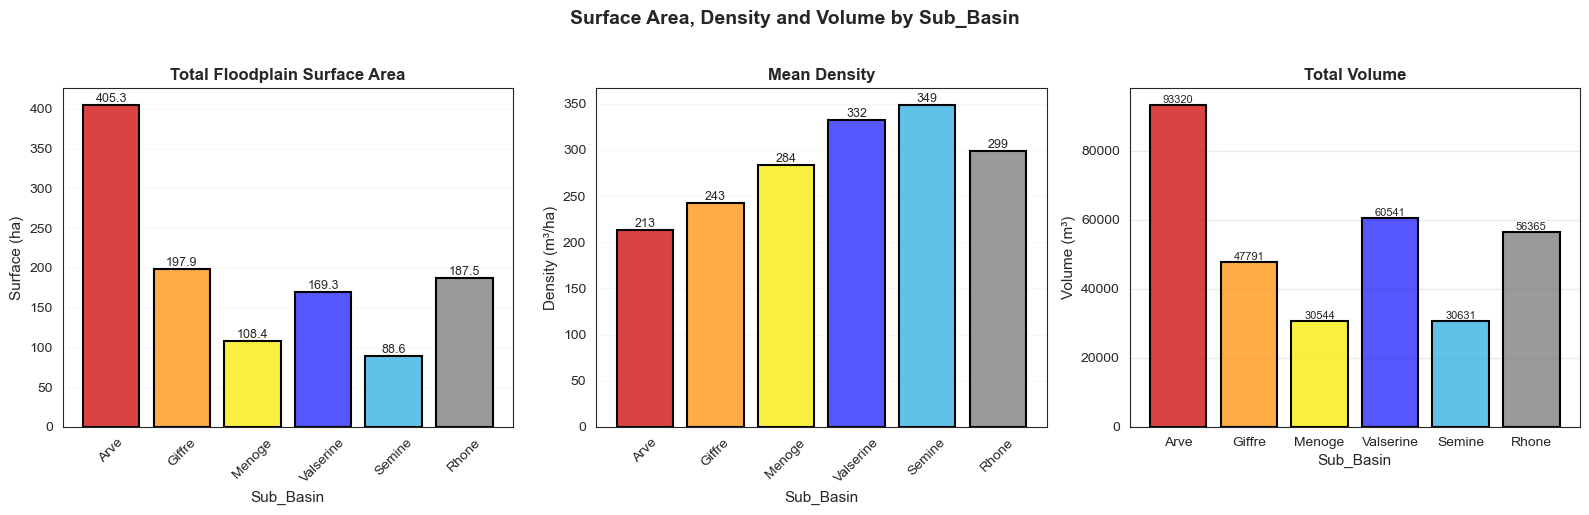

           Surface (ha)  Density (m3/ha)  Volume (m3)
Sub_Basin                                            
Arve             405.31           213.28     93320.25
Giffre           197.95           243.01     47791.01
Menoge           108.40           283.79     30544.25
Valserine        169.33           331.93     60541.09
Semine            88.60           349.17     30630.92
Rhone            187.46           299.33     56365.42

Summary Table:


In [13]:
# Prepare aggregated data by Sub_Basin for comparison chart
summary_stats = df.groupby('Sub_Basin').agg({
    'Surface (ha)': 'sum',
    'Density (m3/ha)': 'mean',
    'Volume (m3)': 'sum'
}).round(2)

# Define desired order of Sub_Basins
desired_order = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']
summary_stats = summary_stats.reindex(desired_order)

# Map colors for each sub-basin
colors = [color_palette.get(basin, '#CCCCCC') for basin in summary_stats.index]

# Create figure with subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total Surface (ha)
ax1 = axes[0]
bars1 = ax1.bar(summary_stats.index, summary_stats['Surface (ha)'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Total Floodplain Surface Area', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sub_Basin', fontsize=11)
ax1.set_ylabel('Surface (ha)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Mean Density (m³/ha)
ax2 = axes[1]
bars2 = ax2.bar(summary_stats.index, summary_stats['Density (m3/ha)'], color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Mean Density', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sub_Basin', fontsize=11)
ax2.set_ylabel('Density (m³/ha)', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Total Volume (m³)
ax3 = axes[2]
bars3 = ax3.bar(summary_stats.index, summary_stats['Volume (m3)'], color=colors, edgecolor='black', linewidth=1.5)
ax3.set_title('Total Volume', fontsize=12, fontweight='bold')
ax3.set_xlabel('Sub_Basin', fontsize=11)
ax3.set_ylabel('Volume (m³)', fontsize=11)
ax3.grid(axis='y', alpha=0.4, linestyle='-', linewidth=1)


# Add value labels on bars
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Surface Area, Density and Volume by Sub_Basin', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

print(summary_stats)

print('\nSummary Table:')

In [14]:
# Create FINT30ByReachAllErrors.csv with all calculations combined
print('\n' + '='*80)
print('CREATING FINT30ByReachAllErrors.csv')
print('='*80)

# Start with FINT30AllData2.csv data (df)
result_df = df.copy()

# Add form factor columns (same value always)
result_df['f_central'] = 0.45
result_df['f_lower'] = 0.4
result_df['f_upper'] = 0.5

# Merge bootstrap results (height statistics) by matching RipUnit with Cod_Plg_2_
# Rename Cod_Plg_2_ to RipUnit for merging with bootstrap_df
bootstrap_df_renamed = bootstrap_df.copy()
bootstrap_df_renamed['RipUnit'] = bootstrap_df_renamed['Cod_Plg_2_']

# Merge on RipUnit
result_df = result_df.merge(
    bootstrap_df_renamed[['RipUnit', 'Median_Height', 'CI_95_Lower', 'CI_95_Upper']],
    on='RipUnit',
    how='left'
)

# Verify columns present
print('\n✓ Columns added from height/bootstrap calculations:')
print(f'  - Median_Height')
print(f'  - CI_95_Lower (height)')
print(f'  - CI_95_Upper (height)')

print('\n✓ Columns from basal area calculations:')
print(f'  - SD_Basal_Area')
print(f'  - SE_Basal_Area')
print(f'  - CI_95_Lower_Basal_Area')
print(f'  - CI_95_Upper_Basal_Area')

print('\n✓ Form factor columns added:')
print(f'  - f_central = 0.45')
print(f'  - f_lower = 0.4')
print(f'  - f_upper = 0.5')

# Export to CSV
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrors.csv')
result_df.to_csv(output_path, index=False)

print(f'\n✓ File exported to: {output_path}')
print(f'\nShape: {result_df.shape}')
print(f'\nFirst 3 rows with key columns:')
print(result_df[['RipUnit', 'Basin', 'Sub_Basin', 'Median_Height', 'CI_95_Lower', 'CI_95_Upper', 
                  'Basal_Area (m2/ha)', 'SD_Basal_Area', 'SE_Basal_Area', 
                  'CI_95_Lower_Basal_Area', 'CI_95_Upper_Basal_Area', 
                  'f_central', 'f_lower', 'f_upper']].head(3))


CREATING FINT30ByReachAllErrors.csv

✓ Columns added from height/bootstrap calculations:
  - Median_Height
  - CI_95_Lower (height)
  - CI_95_Upper (height)

✓ Columns from basal area calculations:
  - SD_Basal_Area
  - SE_Basal_Area
  - CI_95_Lower_Basal_Area
  - CI_95_Upper_Basal_Area

✓ Form factor columns added:
  - f_central = 0.45
  - f_lower = 0.4
  - f_upper = 0.5

✓ File exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrors.csv

Shape: (88, 28)

First 3 rows with key columns:
      RipUnit Basin Sub_Basin  Median_Height  CI_95_Lower  CI_95_Upper  \
0   A-A1-Left  Arve      Arve           17.6        17.10        18.35   
1  A-A1-Right  Arve      Arve           23.1        22.15        24.15   
2   A-A2-Left  Arve      Arve           16.1        15.55        16.75   

   Basal_Area (m2/ha)  SD_Basal_Area  SE_Basal_Area  CI_95_Lower_Basal_Area  \
0            26.88376       2.259901      

In [15]:
# Calculate Density and Volume with uncertainty ranges
print('\n' + '='*80)
print('CALCULATING DENSITY AND VOLUME WITH UNCERTAINTY RANGES')
print('='*80)

# Load FINT30ByReachAllErrors.csv
errors_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrors.csv')
df_errors = pd.read_csv(errors_path)

print(f'\n✓ Loaded: {errors_path}')
print(f'✓ Shape: {df_errors.shape}')

# ============================================================================
# VALIDATION: Verify CI_95_Basal_Area values match checkpoint
# ============================================================================
checkpoint_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30_Basal_Area_CI95_Checkpoint.csv')

if checkpoint_path.exists():
    checkpoint_df = pd.read_csv(checkpoint_path)
    
    # Merge and compare
    comparison = df_errors[['RipUnit', 'CI_95_Lower_Basal_Area', 'CI_95_Upper_Basal_Area']].merge(
        checkpoint_df[['RipUnit', 'CI_95_Lower_Basal_Area', 'CI_95_Upper_Basal_Area']],
        on='RipUnit',
        suffixes=('_current', '_checkpoint')
    )
    
    # Check if values match
    lower_match = (comparison['CI_95_Lower_Basal_Area_current'] == comparison['CI_95_Lower_Basal_Area_checkpoint']).all()
    upper_match = (comparison['CI_95_Upper_Basal_Area_current'] == comparison['CI_95_Upper_Basal_Area_checkpoint']).all()
    
    print(f'\n✓ VALIDATION CHECK against checkpoint:')
    print(f'  - CI_95_Lower_Basal_Area matches checkpoint: {lower_match}')
    print(f'  - CI_95_Upper_Basal_Area matches checkpoint: {upper_match}')
    
    if lower_match and upper_match:
        print(f'  ✓ ✓ ALL CI_95 VALUES VERIFIED FROM CHECKPOINT')
    else:
        print(f'  ⚠ WARNING: CI_95 values differ from checkpoint!')
        print(f'     Using values from FINT30ByReachAllErrors.csv')
else:
    print(f'\n⚠ Checkpoint file not found: {checkpoint_path}')
    print(f'   Proceeding with values from FINT30ByReachAllErrors.csv')

# ============================================================================
# CENTRAL ESTIMATES (using median values and f_central)
# ============================================================================
df_errors['Density_mean (m3/ha)'] = (
    df_errors['Median_Height'] * 
    df_errors['Basal_Area (m2/ha)'] * 
    df_errors['f_central']
)

df_errors['Volume_mean (m3)'] = (
    df_errors['Density_mean (m3/ha)'] * 
    df_errors['Surface (ha)']
)

print('\n✓ CENTRAL estimates calculated:')
print('  - Density_mean (m³/ha) = Median_Height × Basal_Area (m²/ha) × f_central (0.45)')
print('  - Volume_mean (m³) = Density_mean × Surface (ha)')

# ============================================================================
# LOWER ESTIMATES (using CI_95_Lower values and f_lower)
# ============================================================================
df_errors['Density_lower (m3/ha)'] = (
    df_errors['CI_95_Lower'] * 
    df_errors['CI_95_Lower_Basal_Area'] * 
    df_errors['f_lower']
)

print('\n✓ LOWER estimates calculated:')
print('  - Using CI_95_Lower_Basal_Area from checkpoint calculation')
print('  - Density_lower (m³/ha) = CI_95_Lower × CI_95_Lower_Basal_Area × f_lower (0.4)')
print('  - Volume_lower (m³) = Density_lower × Surface (ha)')


CALCULATING DENSITY AND VOLUME WITH UNCERTAINTY RANGES

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrors.csv
✓ Shape: (88, 28)

✓ VALIDATION CHECK against checkpoint:
  - CI_95_Lower_Basal_Area matches checkpoint: True
  - CI_95_Upper_Basal_Area matches checkpoint: True
  ✓ ✓ ALL CI_95 VALUES VERIFIED FROM CHECKPOINT

✓ CENTRAL estimates calculated:
  - Density_mean (m³/ha) = Median_Height × Basal_Area (m²/ha) × f_central (0.45)
  - Volume_mean (m³) = Density_mean × Surface (ha)

✓ LOWER estimates calculated:
  - Using CI_95_Lower_Basal_Area from checkpoint calculation
  - Density_lower (m³/ha) = CI_95_Lower × CI_95_Lower_Basal_Area × f_lower (0.4)
  - Volume_lower (m³) = Density_lower × Surface (ha)


In [16]:
# Export results to FINT30ByReachAllErrorsAndResults.csv
print('\n' + '='*80)
print('EXPORTING RESULTS')
print('='*80)

import time
import os
import shutil

output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrorsAndResults.csv')
temp_path = output_path.parent / (output_path.stem + '_temp.csv')

print('Attempting to save file...\n')

# Strategy 1: Try direct write first
try:
    df_errors.to_csv(output_path, index=False)
    print(f'✓ File exported to: {output_path}')
    print(f'\n✓ Total columns: {len(df_errors.columns)}')
    print(f'✓ Total rows: {len(df_errors)}')
    print(f'\n✓ New columns included:')
    new_cols = ['Density_mean (m3/ha)', 'Density_lower (m3/ha)', 'Density_upper (m3/ha)',
                'Volume_mean (m3)', 'Volume_lower (m3)', 'Volume_upper (m3)']
    for col in new_cols:
        print(f'   - {col}')
    print(f'\n✓ All calculations completed and exported successfully (direct write)')
    
except PermissionError:
    print(f'⚠ File is locked (likely open in Excel/Calc)')
    print(f'  Using temporary file + rename strategy...\n')
    try:
        df_errors.to_csv(temp_path, index=False)
        print(f'✓ Created temp file')
        time.sleep(0.5)
        shutil.move(str(temp_path), str(output_path))
        print(f'✓ Moved temp file to target\n')
        print(f'✓ File exported successfully (via temp file)')
        print(f'✓ Total rows: {len(df_errors)}')
    except Exception as e2:
        print(f'\n✗ ERROR: Could not export file')
        print(f'  File: {output_path}')
        print(f'📋 SOLUTION: Close the file in Excel/other apps and re-run this cell')
        raise
    
except Exception as e:
    print(f'\n✗ ERROR: {type(e).__name__}: {str(e)}')
    raise


EXPORTING RESULTS
Attempting to save file...

✓ File exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrorsAndResults.csv

✓ Total columns: 31
✓ Total rows: 88

✓ New columns included:
   - Density_mean (m3/ha)
   - Density_lower (m3/ha)
   - Density_upper (m3/ha)
   - Volume_mean (m3)
   - Volume_lower (m3)
   - Volume_upper (m3)

✓ All calculations completed and exported successfully (direct write)


In [17]:
df_errors['Volume_lower (m3)'] = (
    df_errors['Density_lower (m3/ha)'] * 
    df_errors['Surface (ha)']
)

# ============================================================================
# UPPER ESTIMATES (using CI_95_Upper values and f_upper)
# ============================================================================
df_errors['Density_upper (m3/ha)'] = (
    df_errors['CI_95_Upper'] * 
    df_errors['CI_95_Upper_Basal_Area'] * 
    df_errors['f_upper']
)

df_errors['Volume_upper (m3)'] = (
    df_errors['Density_upper (m3/ha)'] * 
    df_errors['Surface (ha)']
)

print('\n✓ UPPER estimates calculated:')
print('  - Using CI_95_Upper_Basal_Area from checkpoint calculation')
print('  - Density_upper (m³/ha) = CI_95_Upper × CI_95_Upper_Basal_Area × f_upper (0.5)')
print('  - Volume_upper (m³) = Density_upper × Surface (ha)')

# Display results
print('\n' + '='*80)
print('RESULTS PREVIEW')
print('='*80)

display_cols = [
    'RipUnit', 'Basin', 'Sub_Basin',
    'Density_mean (m3/ha)', 'Density_lower (m3/ha)', 'Density_upper (m3/ha)',
    'Volume_mean (m3)', 'Volume_lower (m3)', 'Volume_upper (m3)'
]

print(f'\nFirst 5 RipUnits:')
print(df_errors[display_cols].head().to_string(index=False))

print(f'\n\nSummary Statistics:')
print('='*80)

summary_cols = {
    'Density_mean (m3/ha)': ('Mean Density (central)', 'mean'),
    'Density_lower (m3/ha)': ('Density (lower bound)', 'mean'),
    'Density_upper (m3/ha)': ('Density (upper bound)', 'mean'),
    'Volume_mean (m3)': ('Total Volume (central)', 'sum'),
    'Volume_lower (m3)': ('Total Volume (lower bound)', 'sum'),
    'Volume_upper (m3)': ('Total Volume (upper bound)', 'sum'),
}

for col, (label, agg) in summary_cols.items():
    if agg == 'mean':
        value = df_errors[col].mean()
        print(f'{label:.<45} {value:>15.2f}')
    else:  # sum
        value = df_errors[col].sum()
        print(f'{label:.<45} {value:>15.0f}')

print('\n✓ All calculations completed successfully')
print(f'\n✓ All Density values use CI_95_Lower_Basal_Area and CI_95_Upper_Basal_Area')
print(f'  from the checkpoint calculation (not from external files)')



✓ UPPER estimates calculated:
  - Using CI_95_Upper_Basal_Area from checkpoint calculation
  - Density_upper (m³/ha) = CI_95_Upper × CI_95_Upper_Basal_Area × f_upper (0.5)
  - Volume_upper (m³) = Density_upper × Surface (ha)

RESULTS PREVIEW

First 5 RipUnits:
   RipUnit Basin Sub_Basin  Density_mean (m3/ha)  Density_lower (m3/ha)  Density_upper (m3/ha)  Volume_mean (m3)  Volume_lower (m3)  Volume_upper (m3)
 A-A1-Left  Arve      Arve            212.919379             164.694699             272.399764       1040.089875         804.517135        1330.645609
A-A1-Right  Arve      Arve            477.542038             339.222887             647.125482       7124.115386        5060.628793        9654.012084
 A-A2-Left  Arve      Arve             70.159711              57.874702              84.278843        242.226401         199.812410         290.972707
A-A2-Right  Arve      Arve             53.297730              44.671728              62.123903        212.076997         177.753274   

In [18]:
# Summary by Sub_Basin: Total Volumes and Surface
print('\n' + '='*80)
print('SUMMARY BY SUB_BASIN: VOLUMES AND SURFACE')
print('='*80)

summary_subbasin = df_errors.groupby('Sub_Basin').agg({
    'Surface (ha)': 'sum',
    'Volume_mean (m3)': 'sum',
    'Volume_lower (m3)': 'sum',
    'Volume_upper (m3)': 'sum'
}).round(2)

# Rename columns for clarity
summary_subbasin.columns = ['Surface (ha)', 'Volume_mean (m3)', 'Volume_lower (m3)', 'Volume_upper (m3)']

# Sort by Sub_Basin name
summary_subbasin = summary_subbasin.sort_index()

print('\n')
print(summary_subbasin.to_string())

print('\n' + '='*80)
print('STATISTICS')
print('='*80)
print(f'\nTotal Surface: {summary_subbasin["Surface (ha)"].sum():.2f} ha')
print(f'Total Volume (mean): {summary_subbasin["Volume_mean (m3)"].sum():.0f} m³')
print(f'Total Volume (lower): {summary_subbasin["Volume_lower (m3)"].sum():.0f} m³')
print(f'Total Volume (upper): {summary_subbasin["Volume_upper (m3)"].sum():.0f} m³')

print('\nVolume ranges by Sub_Basin:')
summary_subbasin['Volume_range (m3)'] = summary_subbasin['Volume_upper (m3)'] - summary_subbasin['Volume_lower (m3)']
print(summary_subbasin[['Volume_lower (m3)', 'Volume_mean (m3)', 'Volume_upper (m3)', 'Volume_range (m3)']].to_string())


SUMMARY BY SUB_BASIN: VOLUMES AND SURFACE


           Surface (ha)  Volume_mean (m3)  Volume_lower (m3)  Volume_upper (m3)
Sub_Basin                                                                      
Arve             405.31          93320.25           69184.28          122128.35
Giffre           197.95          47791.01           34977.03           63498.08
Menoge           108.40          30544.25           22543.56           39909.26
Rhone            187.46          56365.42           41715.06           73677.17
Semine            88.60          30630.92           22151.93           40820.78
Valserine        169.33          60541.09           43083.39           81048.11

STATISTICS

Total Surface: 1157.05 ha
Total Volume (mean): 319193 m³
Total Volume (lower): 233655 m³
Total Volume (upper): 421082 m³

Volume ranges by Sub_Basin:
           Volume_lower (m3)  Volume_mean (m3)  Volume_upper (m3)  Volume_range (m3)
Sub_Basin                                                          

In [19]:
# Calculate Density by Sub_Basin (Volume / Surface)
print('\n' + '='*80)
print('FINAL SUMMARY TABLE BY SUB_BASIN')
print('DENSITY CALCULATED FROM TOTAL VOLUMES AND SURFACES')
print('='*80)

# Create final summary with density calculations
final_summary = summary_subbasin.copy()

# Calculate density for each scenario
# Density = Total Volume / Total Surface
final_summary['Density_mean (m3/ha)'] = (final_summary['Volume_mean (m3)'] / final_summary['Surface (ha)']).round(2)
final_summary['Density_lower (m3/ha)'] = (final_summary['Volume_lower (m3)'] / final_summary['Surface (ha)']).round(2)
final_summary['Density_upper (m3/ha)'] = (final_summary['Volume_upper (m3)'] / final_summary['Surface (ha)']).round(2)

# Reorder columns for better readability
final_summary = final_summary[[
    'Surface (ha)',
    'Volume_mean (m3)',
    'Volume_lower (m3)',
    'Volume_upper (m3)',
    'Density_mean (m3/ha)',
    'Density_lower (m3/ha)',
    'Density_upper (m3/ha)'
]]

print('\n')
print(final_summary.to_string())

print('\n' + '='*80)
print('CALCULATION DETAILS')
print('='*80)

for sub_basin in final_summary.index:
    surface = final_summary.loc[sub_basin, 'Surface (ha)']
    vol_mean = final_summary.loc[sub_basin, 'Volume_mean (m3)']
    vol_lower = final_summary.loc[sub_basin, 'Volume_lower (m3)']
    vol_upper = final_summary.loc[sub_basin, 'Volume_upper (m3)']
    dens_mean = final_summary.loc[sub_basin, 'Density_mean (m3/ha)']
    dens_lower = final_summary.loc[sub_basin, 'Density_lower (m3/ha)']
    dens_upper = final_summary.loc[sub_basin, 'Density_upper (m3/ha)']
    
    print(f'\n{sub_basin}:')
    print(f'  Surface: {surface:.2f} ha')
    print(f'  Volume (mean): {vol_mean:>10.0f} m³ ÷ {surface:>7.2f} ha = {dens_mean:>8.2f} m³/ha')
    print(f'  Volume (lower): {vol_lower:>10.0f} m³ ÷ {surface:>7.2f} ha = {dens_lower:>8.2f} m³/ha')
    print(f'  Volume (upper): {vol_upper:>10.0f} m³ ÷ {surface:>7.2f} ha = {dens_upper:>8.2f} m³/ha')

print('\n' + '='*80)
print('SUMMARY')
print('='*80)
print(f'\nTotal Surface: {final_summary["Surface (ha)"].sum():.2f} ha')
print(f'\nTotal Volumes:')
print(f'  Mean:  {final_summary["Volume_mean (m3)"].sum():>12,.0f} m³')
print(f'  Lower: {final_summary["Volume_lower (m3)"].sum():>12,.0f} m³')
print(f'  Upper: {final_summary["Volume_upper (m3)"].sum():>12,.0f} m³')
print(f'\nMean Densities across all Sub_Basins:')
print(f'  Mean:  {final_summary["Density_mean (m3/ha)"].mean():>12.2f} m³/ha')
print(f'  Lower: {final_summary["Density_lower (m3/ha)"].mean():>12.2f} m³/ha')
print(f'  Upper: {final_summary["Density_upper (m3/ha)"].mean():>12.2f} m³/ha')


FINAL SUMMARY TABLE BY SUB_BASIN
DENSITY CALCULATED FROM TOTAL VOLUMES AND SURFACES


           Surface (ha)  Volume_mean (m3)  Volume_lower (m3)  Volume_upper (m3)  Density_mean (m3/ha)  Density_lower (m3/ha)  Density_upper (m3/ha)
Sub_Basin                                                                                                                                          
Arve             405.31          93320.25           69184.28          122128.35                230.24                 170.69                 301.32
Giffre           197.95          47791.01           34977.03           63498.08                241.43                 176.70                 320.78
Menoge           108.40          30544.25           22543.56           39909.26                281.77                 207.97                 368.17
Rhone            187.46          56365.42           41715.06           73677.17                300.68                 222.53                 393.03
Semine            88.60  

In [20]:
# Export final summary to CSV
print('\n' + '='*80)
print('EXPORTING FINAL SUMMARY')
print('='*80)

import time
import os

output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ResultsBySubBasin.csv')

# Remove existing file if it exists (to avoid permission conflicts)
if output_path.exists():
    try:
        os.remove(output_path)
        print(f'✓ Existing file removed: {output_path.name}')
        time.sleep(0.5)
    except PermissionError:
        print(f'⚠ Warning: Could not remove existing file. It may be open in another application.')
        print(f'  File: {output_path}')
        print(f'  ERROR: Permission denied - file is likely open in Excel or other program')
        print(f'\n  SOLUTION: Close the file and re-run this cell')
        raise

# Export with error handling
try:
    final_summary.to_csv(output_path)

    print(f'\n✓ File exported to: {output_path}')
    print(f'\n✓ Rows: {len(final_summary)} (one per Sub_Basin)')
    print(f'✓ Columns: {len(final_summary.columns)}')

    print(f'\nColumns included:')
    for i, col in enumerate(final_summary.columns, 1):
        print(f'  {i}. {col}')

    print(f'\nFile contents:')
    print(final_summary)
    
except PermissionError as e:
    print(f'\n✗ ERROR: Permission denied when writing file')
    print(f'  File: {output_path}')
    print(f'  SOLUTION: Close the file if open in Excel or other applications, then re-run this cell')
    raise
    
except Exception as e:
    print(f'\n✗ ERROR: Unexpected error writing file')
    print(f'  Error: {type(e).__name__}: {str(e)}')
    raise


EXPORTING FINAL SUMMARY
✓ Existing file removed: FINT30ResultsBySubBasin.csv

✓ File exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ResultsBySubBasin.csv

✓ Rows: 6 (one per Sub_Basin)
✓ Columns: 7

Columns included:
  1. Surface (ha)
  2. Volume_mean (m3)
  3. Volume_lower (m3)
  4. Volume_upper (m3)
  5. Density_mean (m3/ha)
  6. Density_lower (m3/ha)
  7. Density_upper (m3/ha)

File contents:
           Surface (ha)  Volume_mean (m3)  Volume_lower (m3)  \
Sub_Basin                                                      
Arve             405.31          93320.25           69184.28   
Giffre           197.95          47791.01           34977.03   
Menoge           108.40          30544.25           22543.56   
Rhone            187.46          56365.42           41715.06   
Semine            88.60          30630.92           22151.93   
Valserine        169.33          60541.09           43083.39   

      

In [21]:
# Calculate median and mean Basal_Area by Sub_Basin
print('\n' + '='*80)
print('MEDIAN AND MEAN BASAL_AREA BY SUB_BASIN')
print('='*80)

basal_area_stats = df_errors.groupby('Sub_Basin')['Basal_Area (m2/ha)'].agg(['median', 'mean']).round(2)
basal_area_stats.columns = ['Median (m2/ha)', 'Mean (m2/ha)']

print('\n')
print(basal_area_stats.to_string())

print('\n' + '='*80)
print('SUMMARY STATISTICS')
print('='*80)
print(f'\nOverall median Basal_Area: {df_errors["Basal_Area (m2/ha)"].median():.2f} m²/ha')
print(f'Overall mean Basal_Area: {df_errors["Basal_Area (m2/ha)"].mean():.2f} m²/ha')
print(f'Overall min Basal_Area: {df_errors["Basal_Area (m2/ha)"].min():.2f} m²/ha')
print(f'Overall max Basal_Area: {df_errors["Basal_Area (m2/ha)"].max():.2f} m²/ha')

print('\nMedian and Mean Basal_Area by Sub_Basin:')
for sub_basin in basal_area_stats.index:
    median_val = basal_area_stats.loc[sub_basin, 'Median (m2/ha)']
    mean_val = basal_area_stats.loc[sub_basin, 'Mean (m2/ha)']
    print(f'  {sub_basin:.<20} Median: {median_val:>7.2f} m²/ha | Mean: {mean_val:>7.2f} m²/ha')


MEDIAN AND MEAN BASAL_AREA BY SUB_BASIN


           Median (m2/ha)  Mean (m2/ha)
Sub_Basin                              
Arve                24.51         27.14
Giffre              29.08         29.76
Menoge              29.79         30.44
Rhone               33.74         33.13
Semine              34.34         34.15
Valserine           33.98         35.45

SUMMARY STATISTICS

Overall median Basal_Area: 29.87 m²/ha
Overall mean Basal_Area: 30.48 m²/ha
Overall min Basal_Area: 7.24 m²/ha
Overall max Basal_Area: 56.91 m²/ha

Median and Mean Basal_Area by Sub_Basin:
  Arve................ Median:   24.51 m²/ha | Mean:   27.14 m²/ha
  Giffre.............. Median:   29.08 m²/ha | Mean:   29.76 m²/ha
  Menoge.............. Median:   29.79 m²/ha | Mean:   30.44 m²/ha
  Rhone............... Median:   33.74 m²/ha | Mean:   33.13 m²/ha
  Semine.............. Median:   34.34 m²/ha | Mean:   34.15 m²/ha
  Valserine........... Median:   33.98 m²/ha | Mean:   35.45 m²/ha



CREATING BAR CHARTS WITH UNCERTAINTY RANGES

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ResultsBySubBasin.csv
✓ Sub_Basins: ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']


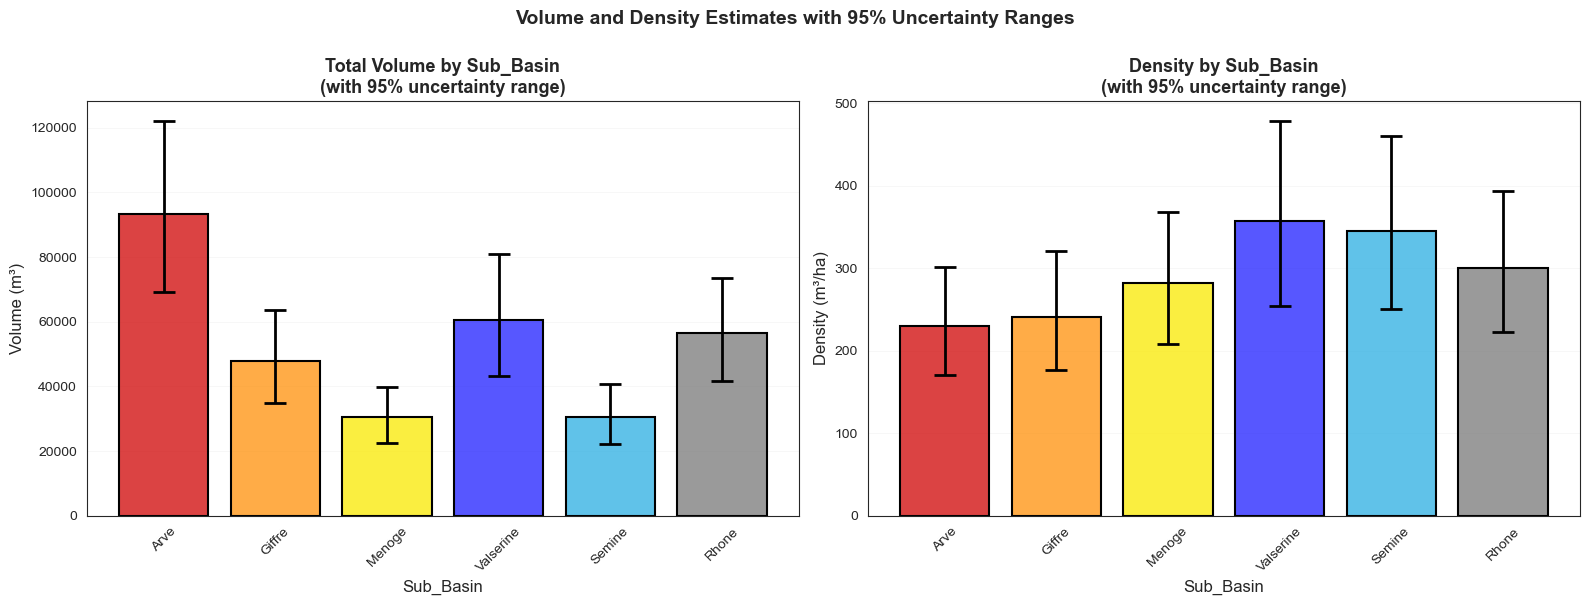


VOLUME RESULTS BY SUB_BASIN


           Volume_mean (m3)  Volume_lower (m3)  Volume_upper (m3)
Sub_Basin                                                        
Arve               93320.25           69184.28          122128.35
Giffre             47791.01           34977.03           63498.08
Menoge             30544.25           22543.56           39909.26
Valserine          60541.09           43083.39           81048.11
Semine             30630.92           22151.93           40820.78
Rhone              56365.42           41715.06           73677.17

DENSITY RESULTS BY SUB_BASIN


           Density_mean (m3/ha)  Density_lower (m3/ha)  Density_upper (m3/ha)
Sub_Basin                                                                    
Arve                     230.24                 170.69                 301.32
Giffre                   241.43                 176.70                 320.78
Menoge                   281.77                 207.97                 368.17
Valserine          

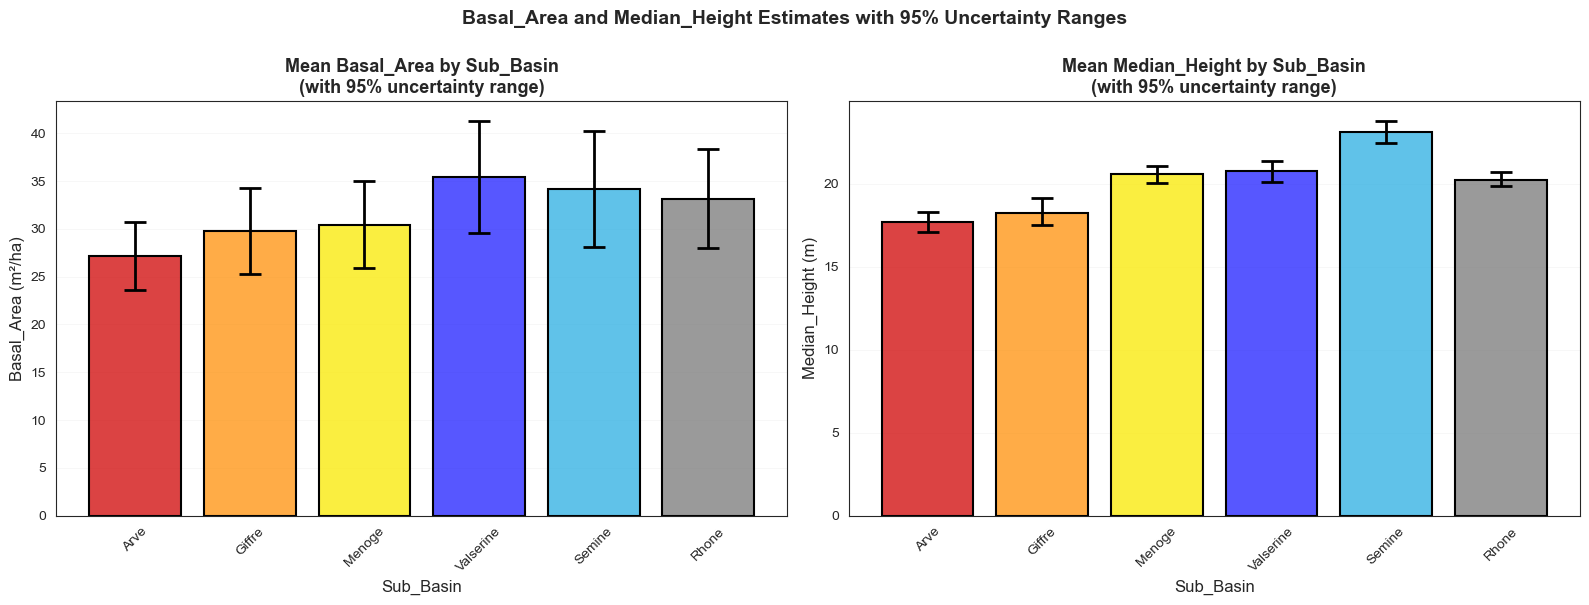


BASAL_AREA RESULTS BY SUB_BASIN


           Basal_Area_mean (m2/ha)  Basal_Area_lower (m2/ha)  Basal_Area_upper (m2/ha)
Sub_Basin                                                                             
Arve                         27.14                     23.56                     30.71
Giffre                       29.76                     25.29                     34.23
Menoge                       30.44                     25.91                     34.98
Valserine                    35.45                     29.60                     41.29
Semine                       34.15                     28.12                     40.18
Rhone                        33.13                     27.96                     38.30

MEDIAN_HEIGHT RESULTS BY SUB_BASIN


           Median_Height_mean (m)  Median_Height_lower (m)  Median_Height_upper (m)
Sub_Basin                                                                          
Arve                        17.68                    17.12     

In [22]:
# Create bar charts with error bars for Volume and Density
print('\n' + '='*80)
print('CREATING BAR CHARTS WITH UNCERTAINTY RANGES')
print('='*80)

# Load FINT30ResultsBySubBasin.csv
results_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ResultsBySubBasin.csv')
results_df = pd.read_csv(results_path, index_col='Sub_Basin')

# Define desired order of Sub_Basins
desired_order = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']
results_df = results_df.reindex(desired_order)

print(f'\n✓ Loaded: {results_path}')
print(f'✓ Sub_Basins: {list(results_df.index)}')

# Map colors for each sub-basin
colors = [color_palette.get(basin, '#CCCCCC') for basin in results_df.index]

# Create figure with subplots for Volume and Density
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================================
# PLOT 1: TOTAL VOLUME WITH ERROR BARS
# ============================================================================
ax1 = axes[0]

# Calculate error bars (difference from mean to upper/lower)
volume_mean = results_df['Volume_mean (m3)']
volume_error_lower = volume_mean - results_df['Volume_lower (m3)']
volume_error_upper = results_df['Volume_upper (m3)'] - volume_mean

# Create bar chart with error bars
bars1 = ax1.bar(results_df.index, volume_mean, color=colors, edgecolor='black', linewidth=1.5, 
                 yerr=[volume_error_lower, volume_error_upper], capsize=8, error_kw={'elinewidth': 2, 'capthick': 2})

ax1.set_title('Total Volume by Sub_Basin\n(with 95% uncertainty range)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Sub_Basin', fontsize=12)
ax1.set_ylabel('Volume (m³)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# ============================================================================
# PLOT 2: MEAN DENSITY WITH ERROR BARS
# ============================================================================
ax2 = axes[1]

# Calculate error bars (difference from mean to upper/lower)
density_mean = results_df['Density_mean (m3/ha)']
density_error_lower = density_mean - results_df['Density_lower (m3/ha)']
density_error_upper = results_df['Density_upper (m3/ha)'] - density_mean

# Create bar chart with error bars
bars2 = ax2.bar(results_df.index, density_mean, color=colors, edgecolor='black', linewidth=1.5,
                 yerr=[density_error_lower, density_error_upper], capsize=8, error_kw={'elinewidth': 2, 'capthick': 2})

ax2.set_title('Density by Sub_Basin\n(with 95% uncertainty range)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Sub_Basin', fontsize=12)
ax2.set_ylabel('Density (m³/ha)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

plt.suptitle('Volume and Density Estimates with 95% Uncertainty Ranges', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================================
# RESULTS TABLE
# ============================================================================
print('\n' + '='*80)
print('VOLUME RESULTS BY SUB_BASIN')
print('='*80)

volume_table = pd.DataFrame({
    'Sub_Basin': results_df.index,
    'Volume_mean (m3)': results_df['Volume_mean (m3)'].values,
    'Volume_lower (m3)': results_df['Volume_lower (m3)'].values,
    'Volume_upper (m3)': results_df['Volume_upper (m3)'].values
}).set_index('Sub_Basin')

print('\n')
print(volume_table.to_string())

print('\n' + '='*80)
print('DENSITY RESULTS BY SUB_BASIN')
print('='*80)

density_table = pd.DataFrame({
    'Sub_Basin': results_df.index,
    'Density_mean (m3/ha)': results_df['Density_mean (m3/ha)'].values,
    'Density_lower (m3/ha)': results_df['Density_lower (m3/ha)'].values,
    'Density_upper (m3/ha)': results_df['Density_upper (m3/ha)'].values
}).set_index('Sub_Basin')

print('\n')
print(density_table.to_string())

print('\n✓ Charts created successfully')

# Create bar charts for Basal_Area and Median_Height with uncertainty ranges
print('\n' + '='*80)
print('CREATING BAR CHARTS FOR BASAL_AREA AND MEDIAN_HEIGHT')
print('='*80)

# Calculate mean values by Sub_Basin
basal_area_by_basin = df_errors.groupby('Sub_Basin').agg({
    'Basal_Area (m2/ha)': 'mean',
    'CI_95_Lower_Basal_Area': 'mean',
    'CI_95_Upper_Basal_Area': 'mean'
}).round(2)

median_height_by_basin = df_errors.groupby('Sub_Basin').agg({
    'Median_Height': 'mean',
    'CI_95_Lower': 'mean',
    'CI_95_Upper': 'mean'
}).round(2)

# Define desired order of Sub_Basins
desired_order = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']
basal_area_by_basin = basal_area_by_basin.reindex(desired_order)
median_height_by_basin = median_height_by_basin.reindex(desired_order)

print(f'\n✓ Basal_Area statistics calculated')
print(f'✓ Median_Height statistics calculated')

# Map colors for each sub-basin
colors = [color_palette.get(basin, '#CCCCCC') for basin in basal_area_by_basin.index]

# Create figure with subplots for Basal_Area and Median_Height
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================================
# PLOT 1: MEAN BASAL_AREA WITH ERROR BARS
# ============================================================================
ax1 = axes[0]

# Calculate error bars (difference from mean to upper/lower)
basal_mean = basal_area_by_basin['Basal_Area (m2/ha)']
basal_error_lower = basal_mean - basal_area_by_basin['CI_95_Lower_Basal_Area']
basal_error_upper = basal_area_by_basin['CI_95_Upper_Basal_Area'] - basal_mean

# Create bar chart with error bars
bars1 = ax1.bar(basal_area_by_basin.index, basal_mean, color=colors, edgecolor='black', linewidth=1.5, 
                 yerr=[basal_error_lower, basal_error_upper], capsize=8, error_kw={'elinewidth': 2, 'capthick': 2})

ax1.set_title('Mean Basal_Area by Sub_Basin\n(with 95% uncertainty range)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Sub_Basin', fontsize=12)
ax1.set_ylabel('Basal_Area (m²/ha)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

# ============================================================================
# PLOT 2: MEAN MEDIAN_HEIGHT WITH ERROR BARS
# ============================================================================
ax2 = axes[1]

# Calculate error bars (difference from mean to upper/lower)
height_mean = median_height_by_basin['Median_Height']
height_error_lower = height_mean - median_height_by_basin['CI_95_Lower']
height_error_upper = median_height_by_basin['CI_95_Upper'] - height_mean

# Create bar chart with error bars
bars2 = ax2.bar(median_height_by_basin.index, height_mean, color=colors, edgecolor='black', linewidth=1.5,
                 yerr=[height_error_lower, height_error_upper], capsize=8, error_kw={'elinewidth': 2, 'capthick': 2})

ax2.set_title('Mean Median_Height by Sub_Basin\n(with 95% uncertainty range)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Sub_Basin', fontsize=12)
ax2.set_ylabel('Median_Height (m)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)

plt.suptitle('Basal_Area and Median_Height Estimates with 95% Uncertainty Ranges', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================================
# RESULTS TABLES
# ============================================================================
print('\n' + '='*80)
print('BASAL_AREA RESULTS BY SUB_BASIN')
print('='*80)

basal_table = pd.DataFrame({
    'Sub_Basin': basal_area_by_basin.index,
    'Basal_Area_mean (m2/ha)': basal_area_by_basin['Basal_Area (m2/ha)'].values,
    'Basal_Area_lower (m2/ha)': basal_area_by_basin['CI_95_Lower_Basal_Area'].values,
    'Basal_Area_upper (m2/ha)': basal_area_by_basin['CI_95_Upper_Basal_Area'].values
}).set_index('Sub_Basin')

print('\n')
print(basal_table.to_string())

print('\n' + '='*80)
print('MEDIAN_HEIGHT RESULTS BY SUB_BASIN')
print('='*80)

height_table = pd.DataFrame({
    'Sub_Basin': median_height_by_basin.index,
    'Median_Height_mean (m)': median_height_by_basin['Median_Height'].values,
    'Median_Height_lower (m)': median_height_by_basin['CI_95_Lower'].values,
    'Median_Height_upper (m)': median_height_by_basin['CI_95_Upper'].values
}).set_index('Sub_Basin')

print('\n')
print(height_table.to_string())

print('\n✓ Charts created successfully')


In [23]:
# Load shape factors CI95 by Cod_Plg
print('\n' + '='*100)
print('LOADING SHAPE FACTORS CI95 DATA')
print('='*100)

ci95_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_ci95_by_codplg.csv')

df_ci95 = pd.read_csv(ci95_path)

print(f'\n✓ Loaded: {ci95_path.name}')
print(f'  Path: {ci95_path.parent}')
print(f'\nShape: {df_ci95.shape}')
print(f'Columns: {list(df_ci95.columns)}')

print(f'\n\nFirst 15 rows:')
print(df_ci95.head(15))

print(f'\n\nSummary statistics:')
print(df_ci95.describe())

print(f'\n✓ Ready: df_ci95 contains shape factors with CI95 by Cod_Plg')


LOADING SHAPE FACTORS CI95 DATA

✓ Loaded: shape_factors_ci95_by_codplg.csv
  Path: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry

Shape: (88, 5)
Columns: ['Cod_Plg', 'f_central', 'f_lower', 'f_upper', 'n']


First 15 rows:
        Cod_Plg  f_central   f_lower   f_upper   n
0     A-A1-Left   0.458430  0.417200  0.527360   9
1    A-A1-Right   0.417730  0.358245  0.510660   6
2    A-A10-Left   0.475110  0.469000  0.476390   3
3   A-A10-Right   0.472695  0.467570  0.503330   4
4    A-A11-Left   0.476390  0.469000  0.503330   3
5   A-A11-Right   0.475750  0.469000  0.503330   4
6    A-A12-Left   0.469000  0.387140  0.493960   7
7   A-A12-Right   0.493960  0.421450  0.527360   5
8    A-A13-Left   0.476390  0.467570  0.503330   7
9   A-A13-Right   0.475750  0.463715  0.498645  10
10   A-A14-Left   0.472055  0.439940  0.510660   6
11  A-A14-Right   0.469000  0.421450  0.527360   5
12   A-A15-Left   0.466720  0.417200  0.476390   9
13  A-A1

In [24]:
# Load VEFm by Diameter Ranges and Genus (Conservative Definition)
print('\n' + '='*100)
print('LOADING VEFm BY DIAMETER RANGES AND GENUS (CONSERVATIVE DEF)')
print('='*100)

vefm_detailed_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\vefm_by_codplg_ci952.csv')

df_vefm_detailed = pd.read_csv(vefm_detailed_path)

print(f'\n✓ VEFm detailed data loaded from:')
print(f'  {vefm_detailed_path}')
print(f'\nShape: {df_vefm_detailed.shape[0]} rows × {df_vefm_detailed.shape[1]} columns')
print(f'\nColumns: {list(df_vefm_detailed.columns)}')
print(f'\nFirst 10 rows:')
print(df_vefm_detailed.head(10).to_string(index=False))


LOADING VEFm BY DIAMETER RANGES AND GENUS (CONSERVATIVE DEF)

✓ VEFm detailed data loaded from:
  C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\vefm_by_codplg_ci952.csv

Shape: 88 rows × 5 columns

Columns: ['Cod_Plg', 'VEFm_central', 'VEFm_lower', 'VEFm_upper', 'n']

First 10 rows:
    Cod_Plg  VEFm_central  VEFm_lower  VEFm_upper  n
  A-A1-Left      1.279174    1.167878    1.379166  9
 A-A1-Right      1.140351    1.101928    1.361453  6
 A-A10-Left      1.269912    1.222849    1.281384  3
A-A10-Right      1.309369    1.244290    1.441520  4
 A-A11-Left      1.348825    1.269912    1.441520  3
A-A11-Right      1.309369    1.222849    1.441520  4
 A-A12-Left      1.279174    1.222970    1.281384  7
A-A12-Right      1.348825    1.217080    1.441520  5
 A-A13-Left      1.348825    1.269912    1.441520  7
A-A13-Right      1.314000    1.244290    1.379166 10


In [25]:
# ============================================================================
# MERGE SHAPE FACTORS + VEFm INTO FINT30 RESULTS
# ============================================================================
print('\n' + '='*100)
print('MERGING SHAPE FACTORS AND VEFm INTO FINT30 RESULTS')
print('='*100)

# Load FINT30ByReachAllErrorsAndResults.csv
fint_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30ByReachAllErrorsAndResults.csv')
df_fint = pd.read_csv(fint_path)

print(f'\n✓ Loaded FINT30 data: {df_fint.shape}')
print(f'  Found f_* columns in FINT30: {[c for c in df_fint.columns if "f_central" in c or "f_lower" in c]}')

# Load and prepare shape factors
df_shape_f = pd.read_csv(Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_ci95_by_codplg.csv'))
df_shape_f_prep = df_shape_f[['Cod_Plg', 'f_central', 'f_lower', 'f_upper']].copy()
df_shape_f_prep.columns = ['RipUnit', 'f_central_new', 'f_lower_new', 'f_upper_new']

# Load and prepare VEFm
df_vefm_ci = pd.read_csv(Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\Genus\vefm_by_codplg_ci952.csv'))
df_vefm_prep = df_vefm_ci[['Cod_Plg', 'VEFm_central', 'VEFm_lower', 'VEFm_upper']].copy()
df_vefm_prep.columns = ['RipUnit', 'VEFm_central', 'VEFm_lower', 'VEFm_upper']

print(f'\n✓ Loaded shape factors: {df_shape_f_prep.shape} | Columns: {df_shape_f_prep.columns.tolist()}')
print(f'✓ Loaded VEFm: {df_vefm_prep.shape} | Columns: {df_vefm_prep.columns.tolist()}')

# Merge: FINT + shape factors + VEFm
df_merged = df_fint.merge(df_shape_f_prep, on='RipUnit', how='left')
df_merged = df_merged.merge(df_vefm_prep, on='RipUnit', how='left')

# Rename the shape factor columns to remove "_new" suffix
df_merged.rename(columns={
    'f_central_new': 'f_central_bootstrap',
    'f_lower_new': 'f_lower_bootstrap', 
    'f_upper_new': 'f_upper_bootstrap'
}, inplace=True)

print(f'\n✓ Final merged: {df_merged.shape}')
print(f'  Shape factor columns: {[c for c in df_merged.columns if "f_central" in c or "f_lower" in c]}')
print(f'  VEFm columns: {[c for c in df_merged.columns if "VEFm_" in c]}')

# Data quality check
print(f'\n✓ Data quality checks:')
print(f'  - f_central_bootstrap nulls: {df_merged["f_central_bootstrap"].isna().sum()} / {len(df_merged)}')
print(f'  - f_lower_bootstrap nulls: {df_merged["f_lower_bootstrap"].isna().sum()} / {len(df_merged)}')
print(f'  - f_upper_bootstrap nulls: {df_merged["f_upper_bootstrap"].isna().sum()} / {len(df_merged)}')
print(f'  - VEFm_central nulls: {df_merged["VEFm_central"].isna().sum()} / {len(df_merged)}')
print(f'  - VEFm_lower nulls: {df_merged["VEFm_lower"].isna().sum()} / {len(df_merged)}')
print(f'  - VEFm_upper nulls: {df_merged["VEFm_upper"].isna().sum()} / {len(df_merged)}')

print(f'\n✓ Complete: Ready for export')


MERGING SHAPE FACTORS AND VEFm INTO FINT30 RESULTS

✓ Loaded FINT30 data: (88, 31)
  Found f_* columns in FINT30: ['f_central', 'f_lower']

✓ Loaded shape factors: (88, 4) | Columns: ['RipUnit', 'f_central_new', 'f_lower_new', 'f_upper_new']
✓ Loaded VEFm: (88, 4) | Columns: ['RipUnit', 'VEFm_central', 'VEFm_lower', 'VEFm_upper']

✓ Final merged: (88, 37)
  Shape factor columns: ['f_central', 'f_lower', 'f_central_bootstrap', 'f_lower_bootstrap']
  VEFm columns: ['VEFm_central', 'VEFm_lower', 'VEFm_upper']

✓ Data quality checks:
  - f_central_bootstrap nulls: 0 / 88
  - f_lower_bootstrap nulls: 0 / 88
  - f_upper_bootstrap nulls: 0 / 88
  - VEFm_central nulls: 0 / 88
  - VEFm_lower nulls: 0 / 88
  - VEFm_upper nulls: 0 / 88

✓ Complete: Ready for export


In [26]:
# ============================================================================
# EXPORT MERGED DATA: FINT30 + Shape Factors Bootstrap CI95 + VEFm CI95
# ============================================================================
import time
import os
import shutil

output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30WithShapeFactorsAndVEFm_CI95.csv')
temp_path = output_path.parent / (output_path.stem + '_temp.csv')

print('Attempting to save file...\n')

# Strategy 1: Try direct write first (file not locked)
try:
    df_merged.to_csv(output_path, index=False)
    print(f'✓ EXPORTED: {output_path.name}')
    print(f'  Shape: {df_merged.shape}')
    print(f'  Columns (first 15): {df_merged.columns.tolist()[:15]}')
    print(f'  Columns (last 15): {df_merged.columns.tolist()[-15:]}')
    print(f'\n✓ New columns added:')
    print(f'  - Bootstrap shape factors: f_central_bootstrap, f_lower_bootstrap, f_upper_bootstrap')
    print(f'  - VEFm bootstrap: VEFm_central, VEFm_lower, VEFm_upper')
    print(f'\n✓ File saved successfully (direct write)')
    
except PermissionError as e:
    print(f'⚠ File is locked (likely open in Excel/Calc)')
    print(f'  Attempting workaround: using temporary file + rename strategy...\n')
    
    try:
        # Strategy 2: Write to temp file, then replace
        df_merged.to_csv(temp_path, index=False)
        print(f'✓ Created temp file: {temp_path.name}')
        time.sleep(1)
        
        # Try to remove old file and rename temp file
        if output_path.exists():
            try:
                os.remove(output_path)
                print(f'✓ Removed old file')
            except PermissionError:
                print(f'⚠ Could not remove old file (still locked)')
                print(f'  Attempting atomic rename operation...')
        
        # Atomic rename (works even if target exists in some cases)
        shutil.move(str(temp_path), str(output_path))
        print(f'✓ Renamed temp file to target\n')
        print(f'✓ EXPORTED: {output_path.name}')
        print(f'  Shape: {df_merged.shape}\n')
        print(f'✓ File saved successfully (via temporary file method)')
        
    except Exception as e2:
        # Strategy 3: Inform user to close file
        print(f'\n✗ ERROR: Could not export file')
        print(f'  File: {output_path}')
        print(f'  Error: {type(e2).__name__}: {str(e2)}\n')
        print(f'📋 SOLUTION:')
        print(f'  1. Close the file in Excel or other open applications')
        print(f'  2. Close the application completely (if needed)')
        print(f'  3. Wait 5 seconds')
        print(f'  4. Re-run this cell\n')
        print(f'If using Excel: Ctrl+W to close the file, or Ctrl+Q to close Excel')
        raise

Attempting to save file...

✓ EXPORTED: FINT30WithShapeFactorsAndVEFm_CI95.csv
  Shape: (88, 37)
  Columns (first 15): ['Id_RipUnit', 'Id_Reach', 'Basin', 'Sub_Basin', 'Reach', 'Bank', 'RipUnit', 'Q25', 'Q50_Median', 'Q75', 'Count', 'Mean (m)', 'Std', 'Basal_Area (m2/ha)', 'Surface (ha)']
  Columns (last 15): ['f_central', 'f_lower', 'f_upper', 'Median_Height', 'CI_95_Lower', 'CI_95_Upper', 'Density_mean (m3/ha)', 'Volume_mean (m3)', 'Density_lower (m3/ha)', 'f_central_bootstrap', 'f_lower_bootstrap', 'f_upper_bootstrap', 'VEFm_central', 'VEFm_lower', 'VEFm_upper']

✓ New columns added:
  - Bootstrap shape factors: f_central_bootstrap, f_lower_bootstrap, f_upper_bootstrap
  - VEFm bootstrap: VEFm_central, VEFm_lower, VEFm_upper

✓ File saved successfully (direct write)


In [27]:
# Diagnose available columns in df_merged
print('\n' + '='*100)
print('DIAGNOSING df_merged COLUMNS')
print('='*100)

print(f'\n✓ Available columns in df_merged ({len(df_merged.columns)} total):')
for i, col in enumerate(df_merged.columns, 1):
    print(f'  {i:2d}. {col}')

# Export merged results with cleanup
print('\n' + '='*100)
print('EXPORTING MERGED RESULTS')
print('='*100)

# Remove unwanted columns - only those that exist
cols_to_drop_candidates = [
    # Original shape factors (keep only bootstrap versions)
    'f_central', 'f_lower', 'f_upper',
    
    # Calculated volume/density columns (not needed)
    'Density_mean (m3/ha)', 'Volume_mean (m3)',
    'Density_lower (m3/ha)', 'Volume_lower (m3)',
    'Density_upper (m3/ha)', 'Volume_upper (m3)',
    'Density (m3/ha)', 'Volume (m3)', 'CV_Basal',
    
    # Basal area statistics (not needed)
    'SD_Basal_Area', 'SE_Basal_Area',
    
    # Individual tree measurements (not needed)
    'Q25', 'Q50_Median', 'Q75', 'Count', 'Mean (m)', 'Std'
]

# Filter to only columns that actually exist
cols_to_drop = [col for col in cols_to_drop_candidates if col in df_merged.columns]

print(f'\n✓ Columns to remove (that exist):')
for col in cols_to_drop:
    print(f'  - {col}')

if len(cols_to_drop) < len(cols_to_drop_candidates):
    missing_cols = [col for col in cols_to_drop_candidates if col not in df_merged.columns]
    print(f'\n⚠ Columns not found (skipping):')
    for col in missing_cols:
        print(f'  - {col}')

df_export = df_merged.drop(columns=cols_to_drop)

# Rename height-related columns
rename_cols = {
    'Median_Height': 'H_Central',
    'CI_95_Lower': 'H_Lower',
    'CI_95_Upper': 'H_Upper',
    'Basal_Area (m2/ha)': 'Basal_central',
    'CI_95_Upper_Basal_Area': 'Basal_Upper',
    'CI_95_Lower_Basal_Area': 'Basal_Lower'
}

# Filter rename dict to only columns that exist
rename_cols_filtered = {old: new for old, new in rename_cols.items() if old in df_export.columns}

df_export.rename(columns=rename_cols_filtered, inplace=True)

print(f'\n✓ Renamed columns:')
for old, new in rename_cols_filtered.items():
    print(f'  - {old} → {new}')

print(f'\n✓ Keeping Bootstrap shape factors & VEFm CI95 + Height CI95')
print(f'  - H_Central, H_Lower, H_Upper')
print(f'  - f_central_bootstrap, f_lower_bootstrap, f_upper_bootstrap')
print(f'  - VEFm_central, VEFm_lower, VEFm_upper')
print(f'  - Basal_central, Basal_Lower, Basal_Upper (con CI del checkpoint)')

# Export cleaned version
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30WithShapeFactorsAndVEFmDefinitive.csv')
df_export.to_csv(output_path, index=False)

print(f'\n✓ File exported to:')
print(f'  {output_path}')

print(f'\n✓ File details:')
print(f'  Rows: {df_export.shape[0]}')
print(f'  Columns: {df_export.shape[1]}')

print(f'\n✓ Final columns:')
for col in df_export.columns:
    print(f'  - {col}')

print(f'\n✓ COMPLETE: FINT30WithShapeFactorsAndVEFmDefinitive.csv exported')


DIAGNOSING df_merged COLUMNS

✓ Available columns in df_merged (37 total):
   1. Id_RipUnit
   2. Id_Reach
   3. Basin
   4. Sub_Basin
   5. Reach
   6. Bank
   7. RipUnit
   8. Q25
   9. Q50_Median
  10. Q75
  11. Count
  12. Mean (m)
  13. Std
  14. Basal_Area (m2/ha)
  15. Surface (ha)
  16. CV_Basal
  17. Density (m3/ha)
  18. Volume (m3)
  19. SD_Basal_Area
  20. SE_Basal_Area
  21. CI_95_Upper_Basal_Area
  22. CI_95_Lower_Basal_Area
  23. f_central
  24. f_lower
  25. f_upper
  26. Median_Height
  27. CI_95_Lower
  28. CI_95_Upper
  29. Density_mean (m3/ha)
  30. Volume_mean (m3)
  31. Density_lower (m3/ha)
  32. f_central_bootstrap
  33. f_lower_bootstrap
  34. f_upper_bootstrap
  35. VEFm_central
  36. VEFm_lower
  37. VEFm_upper

EXPORTING MERGED RESULTS

✓ Columns to remove (that exist):
  - f_central
  - f_lower
  - f_upper
  - Density_mean (m3/ha)
  - Volume_mean (m3)
  - Density_lower (m3/ha)
  - Density (m3/ha)
  - Volume (m3)
  - CV_Basal
  - SD_Basal_Area
  - SE_Basal_

In [28]:
# ============================================================================
# CALCULATE DENSITY AND VOLUME WITH BOOTSTRAP CI95 FOR SHAPE FACTORS AND VEFm
# ============================================================================
print('\n' + '='*100)
print('CALCULATING DENSITY AND VOLUME WITH BOOTSTRAP UNCERTAINTIES')
print('='*100)

# Load FINT30WithShapeFactorsAndVEFmDefinitive.csv
input_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30WithShapeFactorsAndVEFmDefinitive.csv')
df_final = pd.read_csv(input_path)

print(f'\n✓ Loaded: {input_path.name}')
print(f'  Rows: {df_final.shape[0]}')
print(f'  Columns: {df_final.shape[1]}')

# Verify key columns exist
print(f'\n✓ Key columns present:')
key_cols = ['Basal_central', 'Basal_Lower', 'Basal_Upper',
            'H_Central', 'H_Lower', 'H_Upper',
            'f_central_bootstrap', 'f_lower_bootstrap', 'f_upper_bootstrap',
            'VEFm_central', 'VEFm_lower', 'VEFm_upper',
            'Surface (ha)']
for col in key_cols:
    if col in df_final.columns:
        print(f'  ✓ {col}')
    else:
        print(f'  ✗ {col} NOT FOUND')

# ============================================================================
# CENTRAL ESTIMATES (using central values)
# ============================================================================
print(f'\n✓ Calculating CENTRAL estimates:')
print(f'  Density_central = Basal_central × H_Central × f_central_bootstrap × VEFm_central')

df_final['Density_central (m3/ha)'] = (
    df_final['Basal_central'] * 
    df_final['H_Central'] * 
    df_final['f_central_bootstrap'] * 
    df_final['VEFm_central']
).round(4)

df_final['Volume_central (m3)'] = (
    df_final['Density_central (m3/ha)'] * 
    df_final['Surface (ha)']
).round(2)

# ============================================================================
# LOWER ESTIMATES (using lower bounds)
# ============================================================================
print(f'✓ Calculating LOWER estimates:')
print(f'  Density_lower = Basal_Lower × H_Lower × f_lower_bootstrap × VEFm_lower')

df_final['Density_lower (m3/ha)'] = (
    df_final['Basal_Lower'] * 
    df_final['H_Lower'] * 
    df_final['f_lower_bootstrap'] * 
    df_final['VEFm_lower']
).round(4)

df_final['Volume_lower (m3)'] = (
    df_final['Density_lower (m3/ha)'] * 
    df_final['Surface (ha)']
).round(2)

# ============================================================================
# UPPER ESTIMATES (using upper bounds)
# ============================================================================
print(f'✓ Calculating UPPER estimates:')
print(f'  Density_upper = Basal_Upper × H_Upper × f_upper_bootstrap × VEFm_upper')

df_final['Density_upper (m3/ha)'] = (
    df_final['Basal_Upper'] * 
    df_final['H_Upper'] * 
    df_final['f_upper_bootstrap'] * 
    df_final['VEFm_upper']
).round(4)

df_final['Volume_upper (m3)'] = (
    df_final['Density_upper (m3/ha)'] * 
    df_final['Surface (ha)']
).round(2)

print(f'\n✓ New columns created:')
print(f'  - Density_central (m3/ha)')
print(f'  - Density_lower (m3/ha)')
print(f'  - Density_upper (m3/ha)')
print(f'  - Volume_central (m3)')
print(f'  - Volume_lower (m3)')
print(f'  - Volume_upper (m3)')

# Display results
print(f'\n✓ Sample results (first 5 rows):')
display_cols = ['RipUnit', 'Surface (ha)',
                'Density_central (m3/ha)', 'Density_lower (m3/ha)', 'Density_upper (m3/ha)',
                'Volume_central (m3)', 'Volume_lower (m3)', 'Volume_upper (m3)']
print(df_final[display_cols].head())

# Summary statistics
print(f'\n✓ Summary statistics:')
print(f'  Density_central (mean): {df_final["Density_central (m3/ha)"].mean():.4f} m³/ha')
print(f'  Density_lower (mean): {df_final["Density_lower (m3/ha)"].mean():.4f} m³/ha')
print(f'  Density_upper (mean): {df_final["Density_upper (m3/ha)"].mean():.4f} m³/ha')
print(f'\n  Volume_central (total): {df_final["Volume_central (m3)"].sum():.0f} m³')
print(f'  Volume_lower (total): {df_final["Volume_lower (m3)"].sum():.0f} m³')
print(f'  Volume_upper (total): {df_final["Volume_upper (m3)"].sum():.0f} m³')

# Export to CSV
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30Final_DensityVolume.csv')
df_final.to_csv(output_path, index=False)

print(f'\n✓ EXPORTED: {output_path.name}')
print(f'  Rows: {df_final.shape[0]}')
print(f'  Columns: {df_final.shape[1]} (6 new calculation columns)')
print(f'\n✓ Complete')


CALCULATING DENSITY AND VOLUME WITH BOOTSTRAP UNCERTAINTIES

✓ Loaded: FINT30WithShapeFactorsAndVEFmDefinitive.csv
  Rows: 88
  Columns: 20

✓ Key columns present:
  ✓ Basal_central
  ✓ Basal_Lower
  ✓ Basal_Upper
  ✓ H_Central
  ✓ H_Lower
  ✓ H_Upper
  ✓ f_central_bootstrap
  ✓ f_lower_bootstrap
  ✓ f_upper_bootstrap
  ✓ VEFm_central
  ✓ VEFm_lower
  ✓ VEFm_upper
  ✓ Surface (ha)

✓ Calculating CENTRAL estimates:
  Density_central = Basal_central × H_Central × f_central_bootstrap × VEFm_central
✓ Calculating LOWER estimates:
  Density_lower = Basal_Lower × H_Lower × f_lower_bootstrap × VEFm_lower
✓ Calculating UPPER estimates:
  Density_upper = Basal_Upper × H_Upper × f_upper_bootstrap × VEFm_upper

✓ New columns created:
  - Density_central (m3/ha)
  - Density_lower (m3/ha)
  - Density_upper (m3/ha)
  - Volume_central (m3)
  - Volume_lower (m3)
  - Volume_upper (m3)

✓ Sample results (first 5 rows):
      RipUnit  Surface (ha)  Density_central (m3/ha)  Density_lower (m3/ha)  \
0   A

In [32]:
# ============================================================================
# VOLUME AND SURFACE SUMMARY BY SUB_BASIN
# ============================================================================
print('\n' + '='*100)
print('VOLUME AND SURFACE SUMMARY BY SUB_BASIN')
print('='*100)

# Load FINT30Final_DensityVolume.csv
summary_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30Final_DensityVolume.csv')
df_summary = pd.read_csv(summary_path)

print(f'\n✓ Loaded: {summary_path.name}')
print(f'  Rows: {df_summary.shape[0]}')
print(f'  Columns: {df_summary.shape[1]}')

# Aggregate by Sub_Basin
volume_by_subbasin = df_summary.groupby('Sub_Basin').agg({
    'Surface (ha)': 'sum',
    'Volume_central (m3)': 'sum',
    'Volume_lower (m3)': 'sum',
    'Volume_upper (m3)': 'sum'
}).round(2)

print(f'\n✓ Data aggregated by Sub_Basin')
print(f'  Total Sub_Basins: {len(volume_by_subbasin)}')

# Define desired order
desired_order = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']
volume_by_subbasin = volume_by_subbasin.reindex(desired_order)

# Display results
print(f'\n' + '='*100)
print('SUMMARY TABLE: VOLUMES AND SURFACE BY SUB_BASIN')
print('='*100)
print()
print(volume_by_subbasin.to_string())

# Calculate additional statistics
print(f'\n\n' + '='*100)
print('DETAILED BREAKDOWN BY SUB_BASIN')
print('='*100)

for sub_basin in volume_by_subbasin.index:
    surface = volume_by_subbasin.loc[sub_basin, 'Surface (ha)']
    vol_central = volume_by_subbasin.loc[sub_basin, 'Volume_central (m3)']
    vol_lower = volume_by_subbasin.loc[sub_basin, 'Volume_lower (m3)']
    vol_upper = volume_by_subbasin.loc[sub_basin, 'Volume_upper (m3)']
    
    print(f'\n{sub_basin}:')
    print(f'  Surface (ha).......... {surface:>15,.2f}')
    print(f'  Volume_central (m3).. {vol_central:>15,.0f}')
    print(f'  Volume_lower (m3).... {vol_lower:>15,.0f}')
    print(f'  Volume_upper (m3).... {vol_upper:>15,.0f}')
    print(f'  Volume range......... {vol_upper - vol_lower:>15,.0f} m³')

# Global totals
print(f'\n\n' + '='*100)
print('GLOBAL TOTALS')
print('='*100)

total_surface = volume_by_subbasin['Surface (ha)'].sum()
total_vol_central = volume_by_subbasin['Volume_central (m3)'].sum()
total_vol_lower = volume_by_subbasin['Volume_lower (m3)'].sum()
total_vol_upper = volume_by_subbasin['Volume_upper (m3)'].sum()

print(f'\nTotal Surface (all Sub_Basins)...... {total_surface:>15,.2f} ha')
print(f'Total Volume_central (all)......... {total_vol_central:>15,.0f} m³')
print(f'Total Volume_lower (all)........... {total_vol_lower:>15,.0f} m³')
print(f'Total Volume_upper (all)........... {total_vol_upper:>15,.0f} m³')
print(f'Total Volume range................ {total_vol_upper - total_vol_lower:>15,.0f} m³')

# Export to CSV
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30VolumeAndSurfaceBySubBasin.csv')
volume_by_subbasin.to_csv(output_path)

print(f'\n\n✓ EXPORTED: {output_path.name}')
print(f'  Location: {output_path.parent}')
print(f'  Rows: {len(volume_by_subbasin)}')
print(f'  Columns: {len(volume_by_subbasin.columns)}')
print(f'\n✓ Columns in file:')
for i, col in enumerate(volume_by_subbasin.columns, 1):
    print(f'  {i}. {col}')
print(f'\n✓ Complete')


VOLUME AND SURFACE SUMMARY BY SUB_BASIN

✓ Loaded: FINT30Final_DensityVolume.csv
  Rows: 88
  Columns: 26

✓ Data aggregated by Sub_Basin
  Total Sub_Basins: 6

SUMMARY TABLE: VOLUMES AND SURFACE BY SUB_BASIN

           Surface (ha)  Volume_central (m3)  Volume_lower (m3)  Volume_upper (m3)
Sub_Basin                                                                         
Arve             405.31            128966.99           92335.07          172673.44
Giffre           197.95             65853.46           43783.71           94270.59
Menoge           108.40             42127.91           28095.24           58522.36
Valserine        169.33             83472.97           55554.83          112905.15
Semine            88.60             42428.40           27625.40           60506.08
Rhone            187.46             73042.39           50632.57          101572.77


DETAILED BREAKDOWN BY SUB_BASIN

Arve:
  Surface (ha)..........          405.31
  Volume_central (m3)..         128,967
  V

In [34]:
# ============================================================================
# CALCULATE DENSITY FROM VOLUMES AND ADD UNITS
# ============================================================================
print('\n' + '='*100)
print('CALCULATING DENSITY AND ADDING UNITS')
print('='*100)

# Load volume and surface summary
input_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30VolumeAndSurfaceBySubBasin.csv')
df_density = pd.read_csv(input_path, index_col='Sub_Basin')

print(f'\n✓ Loaded: {input_path.name}')
print(f'  Sub_Basins: {len(df_density)}')

# ============================================================================
# CALCULATE DENSITY (m3/ha) = Volume (m3) / Surface (ha)
# ============================================================================
print(f'\n✓ Calculating DENSITY (m³/ha):')
print(f'  Density_central = Volume_central / Surface')
print(f'  Density_lower = Volume_lower / Surface')
print(f'  Density_upper = Volume_upper / Surface')

df_density['Density_central (m3/ha)'] = (
    df_density['Volume_central (m3)'] / df_density['Surface (ha)']
).round(2)

df_density['Density_lower (m3/ha)'] = (
    df_density['Volume_lower (m3)'] / df_density['Surface (ha)']
).round(2)

df_density['Density_upper (m3/ha)'] = (
    df_density['Volume_upper (m3)'] / df_density['Surface (ha)']
).round(2)

# Reorder columns for better readability
final_cols_order = [
    'Surface (ha)',
    'Volume_central (m3)',
    'Volume_lower (m3)',
    'Volume_upper (m3)',
    'Density_central (m3/ha)',
    'Density_lower (m3/ha)',
    'Density_upper (m3/ha)'
]

df_density = df_density[final_cols_order]

print(f'\n✓ New columns created with density calculations')

# Display results
print(f'\n\n' + '='*100)
print('VOLUMES, SURFACE AND DENSITY BY SUB_BASIN (WITH UNITS)')
print('='*100)
print()
print(df_density.to_string())

# Display detailed breakdown
print(f'\n\n' + '='*100)
print('DETAILED BREAKDOWN')
print('='*100)

for sub_basin in df_density.index:
    surface = df_density.loc[sub_basin, 'Surface (ha)']
    vol_central = df_density.loc[sub_basin, 'Volume_central (m3)']
    vol_lower = df_density.loc[sub_basin, 'Volume_lower (m3)']
    vol_upper = df_density.loc[sub_basin, 'Volume_upper (m3)']
    dens_central = df_density.loc[sub_basin, 'Density_central (m3/ha)']
    dens_lower = df_density.loc[sub_basin, 'Density_lower (m3/ha)']
    dens_upper = df_density.loc[sub_basin, 'Density_upper (m3/ha)']
    
    print(f'\n{sub_basin}:')
    print(f'  Surface............... {surface:>12,.2f} ha')
    print(f'  Volume_central........ {vol_central:>12,.0f} m³  →  Density_central = {dens_central:>8.2f} m³/ha')
    print(f'  Volume_lower.......... {vol_lower:>12,.0f} m³  →  Density_lower  = {dens_lower:>8.2f} m³/ha')
    print(f'  Volume_upper.......... {vol_upper:>12,.0f} m³  →  Density_upper  = {dens_upper:>8.2f} m³/ha')

# Global totals
print(f'\n\n' + '='*100)
print('GLOBAL TOTALS')
print('='*100)

total_surface = df_density['Surface (ha)'].sum()
total_vol_central = df_density['Volume_central (m3)'].sum()
total_vol_lower = df_density['Volume_lower (m3)'].sum()
total_vol_upper = df_density['Volume_upper (m3)'].sum()
avg_dens_central = df_density['Density_central (m3/ha)'].mean()
avg_dens_lower = df_density['Density_lower (m3/ha)'].mean()
avg_dens_upper = df_density['Density_upper (m3/ha)'].mean()

print(f'\nTotal Surface (all Sub_Basins)........ {total_surface:>12,.2f} ha')
print(f'Total Volume_central................ {total_vol_central:>12,.0f} m³  →  Average Density = {avg_dens_central:>8.2f} m³/ha')
print(f'Total Volume_lower.................. {total_vol_lower:>12,.0f} m³  →  Average Density = {avg_dens_lower:>8.2f} m³/ha')
print(f'Total Volume_upper.................. {total_vol_upper:>12,.0f} m³  →  Average Density = {avg_dens_upper:>8.2f} m³/ha')

# Export to CSV with units in column names
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30FinalSummaryBySubBasin.csv')
df_density.to_csv(output_path)

print(f'\n\n✓ EXPORTED: {output_path.name}')
print(f'  Rows: {len(df_density)}')
print(f'  Columns: {len(df_density.columns)} (7 columns with units in names)')
print(f'\n✓ Columns in file:')
for i, col in enumerate(df_density.columns, 1):
    print(f'  {i}. {col}')
print(f'\n✓ Complete - All data exported with density calculations and units')


CALCULATING DENSITY AND ADDING UNITS

✓ Loaded: FINT30VolumeAndSurfaceBySubBasin.csv
  Sub_Basins: 6

✓ Calculating DENSITY (m³/ha):
  Density_central = Volume_central / Surface
  Density_lower = Volume_lower / Surface
  Density_upper = Volume_upper / Surface

✓ New columns created with density calculations


VOLUMES, SURFACE AND DENSITY BY SUB_BASIN (WITH UNITS)

           Surface (ha)  Volume_central (m3)  Volume_lower (m3)  Volume_upper (m3)  Density_central (m3/ha)  Density_lower (m3/ha)  Density_upper (m3/ha)
Sub_Basin                                                                                                                                                
Arve             405.31            128966.99           92335.07          172673.44                   318.19                 227.81                 426.03
Giffre           197.95             65853.46           43783.71           94270.59                   332.68                 221.19                 476.23
Menoge          


CREATING BAR CHARTS WITH UNCERTAINTY RANGES (VOLUME & DENSITY)

✓ Loaded: FINT30FinalSummaryBySubBasin.csv
  Sub_Basins: 6

✓ Color palette applied to 6 Sub_Basins


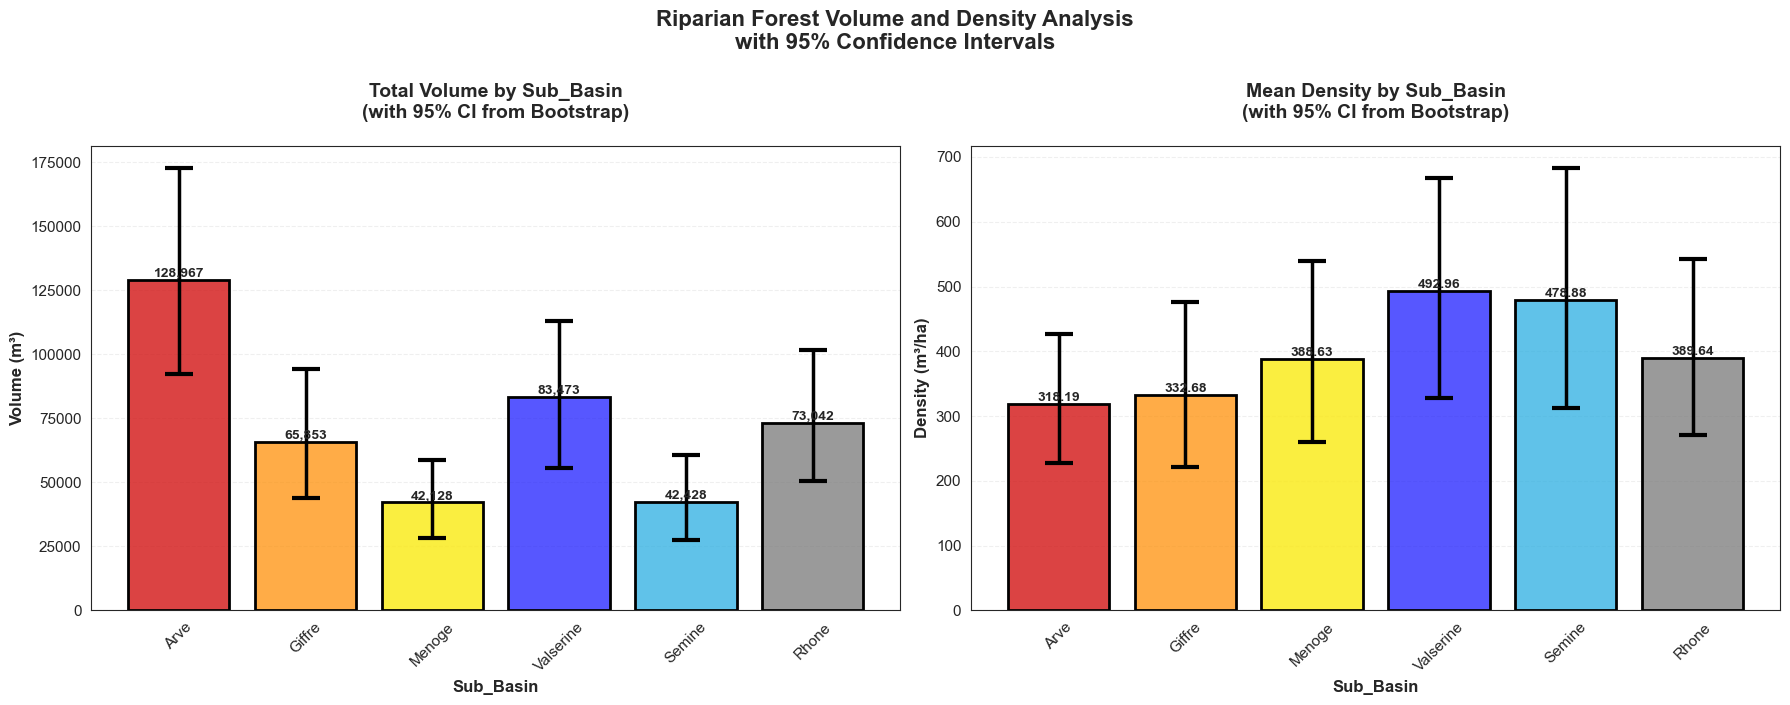


✓ Charts created successfully

VOLUME AND DENSITY SUMMARY BY SUB_BASIN

           Volume_central (m3)  Volume_lower (m3)  Volume_upper (m3)  Density_central (m3/ha)  Density_lower (m3/ha)  Density_upper (m3/ha)
Sub_Basin                                                                                                                                  
Arve                 128966.99           92335.07          172673.44                   318.19                 227.81                 426.03
Giffre                65853.46           43783.71           94270.59                   332.68                 221.19                 476.23
Menoge                42127.91           28095.24           58522.36                   388.63                 259.18                 539.87
Valserine             83472.97           55554.83          112905.15                   492.96                 328.09                 666.78
Semine                42428.40           27625.40           60506.08                   

In [35]:
# ============================================================================
# BAR CHARTS WITH ERROR BARS: VOLUME AND DENSITY BY SUB_BASIN
# ============================================================================
print('\n' + '='*100)
print('CREATING BAR CHARTS WITH UNCERTAINTY RANGES (VOLUME & DENSITY)')
print('='*100)

# Load FINT30FinalSummaryBySubBasin.csv
chart_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\VolumesBasinAndFint\FINT30FinalSummaryBySubBasin.csv')
df_chart = pd.read_csv(chart_path, index_col='Sub_Basin')

print(f'\n✓ Loaded: {chart_path.name}')
print(f'  Sub_Basins: {len(df_chart)}')

# Define desired order
desired_order = ['Arve', 'Giffre', 'Menoge', 'Valserine', 'Semine', 'Rhone']
df_chart = df_chart.reindex(desired_order)

# Map colors for each sub-basin
colors = [color_palette.get(basin, '#CCCCCC') for basin in df_chart.index]

print(f'\n✓ Color palette applied to {len(df_chart)} Sub_Basins')

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# PLOT 1: TOTAL VOLUME WITH ERROR BARS
# ============================================================================
ax1 = axes[0]

# Calculate error bars (from central to lower/upper)
volume_central = df_chart['Volume_central (m3)']
volume_error_lower = volume_central - df_chart['Volume_lower (m3)']
volume_error_upper = df_chart['Volume_upper (m3)'] - volume_central

# Create bar chart with error bars
bars1 = ax1.bar(
    df_chart.index, 
    volume_central, 
    color=colors, 
    edgecolor='black', 
    linewidth=2,
    yerr=[volume_error_lower, volume_error_upper], 
    capsize=10, 
    error_kw={'elinewidth': 2.5, 'capthick': 3, 'ecolor': 'black'}
)

ax1.set_title('Total Volume by Sub_Basin\n(with 95% CI from Bootstrap)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Sub_Basin', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume (m³)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, volume_central)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============================================================================
# PLOT 2: MEAN DENSITY WITH ERROR BARS
# ============================================================================
ax2 = axes[1]

# Calculate error bars (from central to lower/upper)
density_central = df_chart['Density_central (m3/ha)']
density_error_lower = density_central - df_chart['Density_lower (m3/ha)']
density_error_upper = df_chart['Density_upper (m3/ha)'] - density_central

# Create bar chart with error bars
bars2 = ax2.bar(
    df_chart.index, 
    density_central, 
    color=colors, 
    edgecolor='black', 
    linewidth=2,
    yerr=[density_error_lower, density_error_upper], 
    capsize=10, 
    error_kw={'elinewidth': 2.5, 'capthick': 3, 'ecolor': 'black'}
)

ax2.set_title('Mean Density by Sub_Basin\n(with 95% CI from Bootstrap)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Sub_Basin', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density (m³/ha)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=11)
ax2.tick_params(axis='y', labelsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars2, density_central)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Overall title
plt.suptitle('Riparian Forest Volume and Density Analysis\nwith 95% Confidence Intervals', 
             fontsize=16, fontweight='bold', y=1.00)

plt.tight_layout()
plt.show()

print(f'\n✓ Charts created successfully')

# Print summary statistics
print(f'\n' + '='*100)
print('VOLUME AND DENSITY SUMMARY BY SUB_BASIN')
print('='*100)
print()

summary_data = pd.DataFrame({
    'Volume_central (m3)': df_chart['Volume_central (m3)'],
    'Volume_lower (m3)': df_chart['Volume_lower (m3)'],
    'Volume_upper (m3)': df_chart['Volume_upper (m3)'],
    'Density_central (m3/ha)': df_chart['Density_central (m3/ha)'],
    'Density_lower (m3/ha)': df_chart['Density_lower (m3/ha)'],
    'Density_upper (m3/ha)': df_chart['Density_upper (m3/ha)']
})

print(summary_data.to_string())

print(f'\n✓ Complete - Charts with error bars created and displayed')